###Curso de Data Science

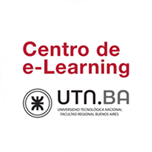

***
#Trabajo Práctico Final: **"Predicción de datos petrofísicos para su implementación en el análisis de reservas y simulación de producción de hidrocarburos"**.
***

*Alumna*: Ing. Paula García Quenardelle

*Docente*: Ing. Virginia Marich

Comisión N°: 999197810

Año: 2025

# Introducción

En la industria del Oil & Gas, particularmente en las etapas de exploración, desarrollo y producción de hidrocarburos, se generan y procesan millones de datos que constituyen la base para la optimización y mejora continua de los distintos procesos operativos y de análisis. La correcta gestión, integración e interpretación de esta información resulta esencial para reducir incertidumbres, fortalecer la toma de decisiones y maximizar la eficiencia en todas las fases del ciclo de vida de un yacimiento.

En este contexto, es importante comprender cómo se alojan y se movilizan los hidrocarburos en el subsuelo. Aunque suele imaginarse que el petróleo y el gas se acumulan en grandes cavidades subterráneas, en realidad estos recursos se encuentran alojados dentro de diminutos poros presentes entre los granos de la roca. A través de esta red microscópica de espacios interconectados se almacenan y desplazan los fluidos, lo que define la capacidad del reservorio para contener y transmitir hidrocarburos.

Los datos petrofísicos constituyen el conjunto de propiedades físicas que caracterizan a las rocas que almacenan y controlan el flujo de los hidrocarburos en el subsuelo, tales como porosidad, permeabilidad, saturación de fluidos y densidad, entre otras. Estas variables son fundamentales para caracterizar los yacimientos y comprender su comportamiento dinámico frente a diferentes condiciones de explotación. En el ámbito de la ingeniería de reservorios, la disponibilidad de datos petrofísicos confiables permite alimentar los modelos estáticos y dinámicos utilizados en los simuladores de reservas, facilitando la estimación del volumen original de hidrocarburos, la evaluación de escenarios de producción y la toma de decisiones para optimizar la recuperación del yacimiento.




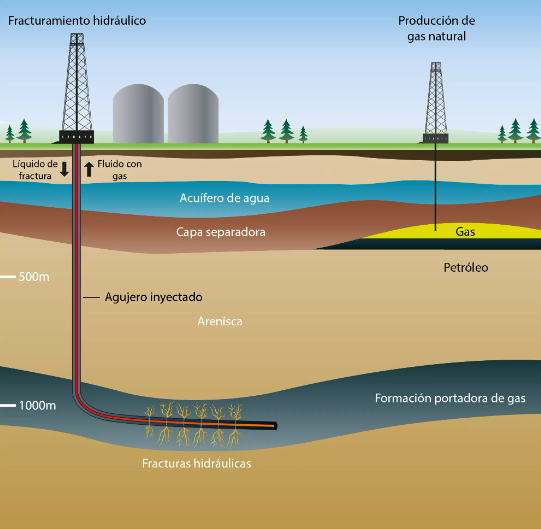

## Propiedades Petrofísicas

La base de datos analizada contiene información de mediciones petrofísicas de laboratorio realizadas sobre muestras de roca provenientes de distintos pozos operados por dos compañías en Argentina. Estas mediciones se obtienen a partir de muestras extraídas durante la perforación, ya sea mediante coronas (testigos continuos obtenidos durante el avance del pozo) o, cuando esto no es posible, mediante testigos laterales rotados (sidewall cores), una técnica ampliamente utilizada para obtener muestras puntuales del intervalo de interés.

Los parámetros fundamentales que se evaluarán en detalle se describen a continuación:

1. *Porosidad* (φ): expresa la proporción del volumen de poros respecto del volumen total de la roca, e indica su capacidad de almacenamiento de fluidos. Se expresa en fracción o porcentaje (%).

2. *Permeabilidad* (k): describe la capacidad de la roca para permitir el flujo de fluidos a través de su red de poros interconectados. Se mide en milidarcys (mD) o darcys (D).

3. *Densidad de grano* (ρg): propiedad que refleja la composición mineralógica y el grado de compactación de la roca. Se expresa en g/cm³.

4. *Densidad aparente* (ρb): también denominada bulk density, corresponde a la masa total de la muestra (incluyendo sólidos y poros) por unidad de volumen. Es un parámetro clave para evaluar la compactación y estimar la porosidad total. Se expresa en g/cm³.

Además, otras propiedades relevantes para el análisis incluyen:

* *Profundidad*: indica la posición vertical del intervalo muestreado dentro del pozo y condiciona parámetros como presión, compactación y calidad del reservorio. Se expresa en metros (m) o pies (ft).

* *Condiciones de medición*: especifican si las propiedades petrofísicas fueron determinadas bajo condiciones estándar de laboratorio (STD) o bajo condiciones de presión de reservorio, NOBP (Net Overburden Pressure).

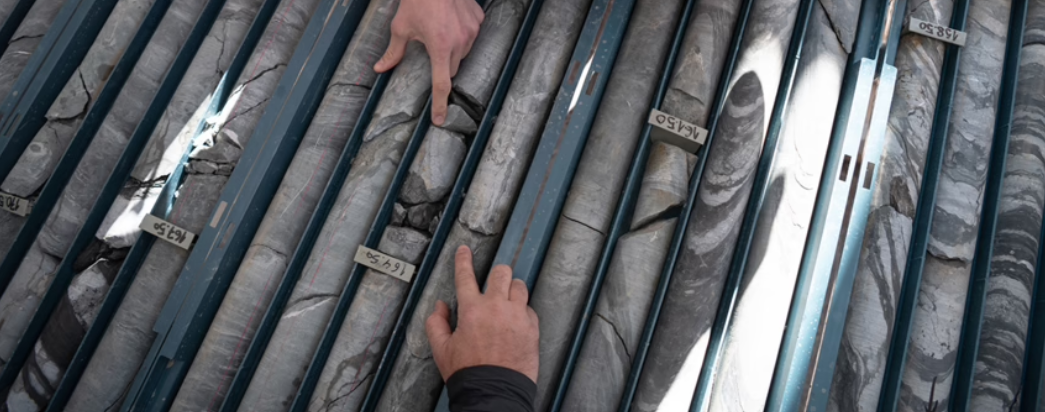

## Objetivos

El análisis de laboratorio de las muestras de roca tiene varias limitaciones, entre ellas: no siempre se cuenta con muestras, algunas propiedades son costosas de medir, los equipos requieren tiempos largos de estabilización, y muchas veces hay diferencias entre las condiciones reales del reservorio y las reproducibles en laboratorio. Como consecuencia, es habitual encontrar bases de datos incompletas, heterogéneas o con valores faltantes.

En este contexto, la ciencia de datos ofrece herramientas poderosas para complementar y mejorar la interpretación petrofísica tradicional. A través de técnicas de análisis exploratorio, modelado estadístico y aprendizaje automático, es posible:

- Identificar relaciones entre variables petrofísicas que no son evidentes a simple vista.
- Predecir propiedades faltantes cuando no existen mediciones de laboratorio.
- Corregir o estimar mediciones bajo condiciones distintas (por ejemplo, estimar datos a NOBP a partir de los datos STD).
- Reducir incertidumbres en la caracterización del yacimiento y mejorar el cálculo de reservas.

En este proyecto se trabaja con una serie de datos petrofísicos provenientes de pozos de Argentina, obtenidos de testigos laterales rotados y sus mediciones de laboratorio asociadas. El objetivo principal es analizar estas variables, evaluar la relación entre parámetros y desarrollar modelos predictivos que permitan estimar propiedades clave.

**El objetivo particular será lograr predecir la NOBP, la porosidad y la permeabilidad (éstas dos últimas, tanto en condiciones STD como en condiciones NOBP) partiendo de los datos más fáciles de obtener de una muestra, la densidad aparente y la profundidad.**

La capacidad de predecir estas propiedades con modelos confiables resulta especialmente valiosa en etapas tempranas de evaluación de un campo, o en zonas donde se dispone de poca información. Modelos de este tipo permiten avanzar en la estimación de reservas sin depender exclusivamente de datos de laboratorio, optimizando tiempos, recursos y decisiones técnicas.

Por lo tanto, este proyecto no solo busca aplicar herramientas de Data Science, sino también demostrar su utilidad práctica en un entorno real de la industria petrolera, integrando enfoques de ingeniería y análisis de datos para enriquecer la caracterización del subsuelo y su aprovechamiento eficiente.

# Datos Petrofísicos


Para comenzar el trabajo con el dataset, se procederá a importar las librerías que se utilizarán a lo largo de todo el análisis, así como el propio conjunto de datos.

In [1]:
#Importo las librerias a emplear en todo el trabajo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from IPython.display import display, clear_output
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, HBox, VBox
from scipy.stats import gaussian_kde
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tqdm import tqdm

##Importación del Dataset

In [2]:
#Importo la información del dataset de Excel desde Google Drive

df = pd.read_excel('/content/drive/MyDrive/ds2025/Datos TLR.xlsx')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


El dataset disponible está compuesto por 502 filas con datos y 34 columnas de parámetros de medición. Para poder trabajar correctamente con el conjunto de datos, se realizará una limpieza del dataset donde se eliminará toda aquella información faltante, nula o irrelevante para el presente trabajo. A continuación, se realizará la exploración, limpieza y transformación de la información, con el objetivo de obtener un dataset depurado y consistente, más adecuado para el análisis de correlaciones y el desarrollo de modelos predictivos entre las distintas variables.

## Exploración del Dataset

In [4]:
#Evalúo la información que brinda el Dataset

display(df.head())
display(df.tail())

,Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Prof. [m],Peso Seco [g],V Ap [cm3],D Ap [g/cm3],VP [cm3],...,VP NOBP [cm3],PHI NOBP [%],NOBP [psi],Fecha PHI NOBP,Longitud [cm],Diametro [cm],Kg STD[mD],Fecha Kg STD,Kg NOBP [mD],Fecha Kg NOBP
0,3671,0,TLR,CS-2297,1,1641.5,22.91,10.693145,2.142494,1.973506,...,2.213103,16.917896,3066.0,2021-08-19 00:00:00,2.478667,2.351333,6.11,0,4.49,0.0
1,3671,0,TLR,CS-2297,2,1645.5,26.56,12.556681,2.115209,2.308109,...,2.528310,16.884112,3074.0,2021-08-18 00:00:00,2.972333,2.329333,0.552,0,0.371,0.0
2,3671,0,TLR,CS-2297,3,1646.8,18.94,9.325073,2.031083,2.114649,...,2.368491,21.174686,3076.0,2021-08-19 00:00:00,2.186333,2.348333,121,0,108,0.0
3,3671,0,TLR,CS-2297,5,1708.0,20.77,8.726080,2.380221,0.836961,...,1.124289,8.250656,3189.0,2021-08-19 00:00:00,2.042333,2.354333,0.00911,0,0.00258,0.0
4,3671,0,TLR,CS-2297,6,1709.0,20.60,9.495158,2.169527,1.668864,...,1.890206,15.590523,3190.0,2021-08-18 00:00:00,2.303667,2.319333,0.156,0,0.0634,0.0


,Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Prof. [m],Peso Seco [g],V Ap [cm3],D Ap [g/cm3],VP [cm3],...,VP NOBP [cm3],PHI NOBP [%],NOBP [psi],Fecha PHI NOBP,Longitud [cm],Diametro [cm],Kg STD[mD],Fecha Kg STD,Kg NOBP [mD],Fecha Kg NOBP
498,4035,0,TLR,LACh-39(h),10,950.0,35.92,17.219430,2.086016,3.588672,...,3.522761,20.454504,1910.0,2025-02-17 00:00:00,4.089,2.341,4.35,0,3.37,0.0
499,4035,0,TLR,LACh-39(h),11,928.0,35.19,17.043197,2.064753,3.598169,...,3.520422,20.651992,1871.0,2025-02-17 00:00:00,4.048,2.331,0.508,0,0.402,0.0
500,4035,0,TLR,LACh-39(h),12,887.0,35.14,16.925708,2.076132,3.501114,...,3.431444,20.268291,1796.0,2025-02-17 00:00:00,4.008,2.332,37.2,0,28.7,0.0
501,4035,0,TLR,LACh-39(h),13,847.0,39.68,18.658666,2.126626,3.059057,...,2.979603,17.157696,1724.0,2025-02-17 00:00:00,4.434,2.314,0.361,0,0.252,0.0
502,4035,0,TLR,LACh-39(h),14,815.0,39.29,18.100595,2.170647,3.076858,...,3.021270,16.675839,1666.0,2025-02-17 00:00:00,4.276,2.340,0.212,0,0.144,0.0


## Información de los parámetros del Dataset

In [5]:
#Me fijo que parámetros y cantidad de información tengo

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Proyecto             503 non-null    int64  
 1   ID Empresa           503 non-null    int64  
 2   Tipo Muestra         503 non-null    object 
 3   Pozo                 503 non-null    object 
 4   Muestra              503 non-null    object 
 5   Prof. [m]            503 non-null    float64
 6   Peso Seco [g]        503 non-null    float64
 7   V Ap [cm3]           503 non-null    float64
 8   D Ap [g/cm3]         501 non-null    float64
 9   VP [cm3]             503 non-null    float64
 10  Pref [psi]           503 non-null    float64
 11  P Holder [psi]       503 non-null    float64
 12  Temp [ºC]            503 non-null    float64
 13  VR [cm3]             503 non-null    float64
 14  Dreal [g/cm3]        503 non-null    float64
 15  PHI [%]              503 non-null    obj

None

## Limpieza y Transformación del Dataset

### Elimino las columnas que no voy a emplear en el desarrollo

In [6]:
df = df.drop(columns=["Peso Seco [g]", "V Ap [cm3]", "VP [cm3]", "Pref [psi]",
                      "P Holder [psi]", "Temp [ºC]", "VR [cm3]","Vref [cm3]",
                      "Vc [cm3]", "Contrapeso", "Fecha PHI STD", "Pref NOBP [psi]",
                      "P.Holder STD [psi]", "P.Holder NOBP [psi]", "VP 500 [cm3]",
                      "VP NOBP [cm3]", "Fecha PHI NOBP", "Longitud [cm]",
                      "Diametro [cm]", "Fecha Kg STD", "Fecha Kg NOBP"])

### Renombro las columnas

In [7]:
df = df.rename(columns={'Proyecto': 'N° Proyecto',
                        'Prof. [m]': 'Profundidad',
                        'D Ap [g/cm3]': 'Densidad Aparente',
                        'Dreal [g/cm3]': 'Densidad de Grano',
                        'PHI [%]': 'Porosidad STD',
                        'PHI NOBP [%]': 'Porosidad NOBP',
                        'NOBP [psi]': 'NOBP',
                        'Kg STD[mD]': 'Permeabilidad STD',
                        'Kg NOBP [mD]': 'Permeabilidad NOBP',
                        })

### Busco filas duplicadas

In [8]:
df_clean = df.drop_duplicates()

No tenemos filas duplicadas que eliminar.

### Chequeo de columnas con valores faltantes "NaN" y reemplazo con ceros

In [9]:
#Busco las columnas con valores faltantes
print("Valores faltantes por columna antes de llenar:")
display(df.isnull().sum())

# Llenamos todos los valores faltantes con ceros
df.fillna(0, inplace=True)

# Verificamos que ya no haya valores faltantes
print("\nValores faltantes por columna después de llenar con ceros:")
display(df.isnull().sum())

Valores faltantes por columna antes de llenar:


,0
N° Proyecto,0
ID Empresa,0
Tipo Muestra,0
Pozo,0
Muestra,0
Profundidad,0
Densidad Aparente,2
Densidad de Grano,0
Porosidad STD,0
Porosidad NOBP,0



Valores faltantes por columna después de llenar con ceros:


,0
N° Proyecto,0
ID Empresa,0
Tipo Muestra,0
Pozo,0
Muestra,0
Profundidad,0
Densidad Aparente,0
Densidad de Grano,0
Porosidad STD,0
Porosidad NOBP,0


###Búsqueda y revisión de valores nulos en todas las columnas

In [10]:
#De las columnas con las que voy a trabajar me fijo cuántos valores nulos tengo

columns_check = ['N° Proyecto', 'ID Empresa', 'Tipo Muestra', 'Pozo', 'Muestra', 'Profundidad','Densidad Aparente', 'Densidad de Grano', 'Porosidad STD', 'Porosidad NOBP',
                 'NOBP','Permeabilidad STD', 'Permeabilidad NOBP']

for col in columns_check:
    count_zeros = (df[col] == 0).sum()
    print(f"Columna '{col}': {count_zeros} valores cero")

Columna 'N° Proyecto': 0 valores cero
Columna 'ID Empresa': 219 valores cero
Columna 'Tipo Muestra': 0 valores cero
Columna 'Pozo': 0 valores cero
Columna 'Muestra': 0 valores cero
Columna 'Profundidad': 0 valores cero
Columna 'Densidad Aparente': 12 valores cero
Columna 'Densidad de Grano': 11 valores cero
Columna 'Porosidad STD': 7 valores cero
Columna 'Porosidad NOBP': 33 valores cero
Columna 'NOBP': 40 valores cero
Columna 'Permeabilidad STD': 20 valores cero
Columna 'Permeabilidad NOBP': 20 valores cero


La variable ID Empresa adopta valores discretos 0 o 1 para identificar a la operadora correspondiente. En este caso, los valores iguales a cero no representan datos faltantes, sino que corresponden a una codificación cualitativa asociada a una tabla externa de la cual no se dispone información adicional.

En contraste, los valores nulos presentes en el resto de las variables petrofísicas sí resultan significativos. Para parámetros como densidad aparente, densidad de grano, porosidad STD, NOBP, porosidad NOBP, permeabilidad STD y permeabilidad NOBP, la ausencia de datos implica que la medición no fue realizada sobre la muestra correspondiente, lo que limita su utilidad para el análisis.

Por este motivo, se abordará el tratamiento de valores nulos columna por columna, evaluando en cada caso la conveniencia de reemplazar dichos valores mediante técnicas estadísticas apropiadas o eliminarlos, con el objetivo de preservar la consistencia y calidad del dataset final.

1. Columna "Densidad Aparente"

In [11]:
#Reviso los datos nulos en Densidad Aparente

df_dap_cero = df[df['Densidad Aparente'] == 0]

display(df_dap_cero)

,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
37,3680,1,TLR,PZ-1569,32,1125.00,0.0,0.000000,0,0,0.000000,0,0
39,3680,1,TLR,PZ-1569,30,1170.02,0.0,0.000000,0,0,0.000000,0,0
42,3680,1,TLR,PZ-1569,27,1353.54,0.0,0.000000,0,0,0.000000,0,0
43,3680,1,TLR,PZ-1569,24,1358.02,0.0,0.000000,0,0,0.000000,0,0
44,3680,1,TLR,PZ-1569,23,1440.05,0.0,0.000000,0,0,0.000000,0,0
45,3680,1,TLR,PZ-1569,22,1444.99,0.0,0.000000,0,0,0.000000,0,0
96,3697,1,TLR,PVH-1374,23,1203.00,0.0,0.000000,0,N / D,2040.914794,N / D,N / D
123,3733,0,TLR,CMoE.a-82,6,611.70,0.0,0.000000,N / D,N / D,1362.000000,N / D,N / D
137,3734,0,TLR,Lcav-133(h),19,1569.00,0.0,0.000000,N / D,N / D,0.000000,N / D,N / D
150,3734,0,TLR,Lcav-133(h),26,1787.46,0.0,0.000000,N / D,N / D,3413.616000,N / D,N / D


Se observa que, para un único registro (fila 288), el valor de densidad aparente es el único dato faltante, mientras que el resto de los parámetros petrofísicos se encuentran completos. Dado que se trata de un caso aislado, se decide estimar este valor faltante con el objetivo de conservar la información restante de la muestra y evitar la eliminación innecesaria de un registro potencialmente valioso.

Para ello, se identificarán aquellas filas que presenten valores de densidad de grano similares, definiendo previamente una tolerancia adecuada. A partir de este subconjunto, se calculará el valor promedio de la densidad aparente, el cual será utilizado como estimación para completar el dato faltante correspondiente a la fila 288.

In [12]:
# Obtener el valor de referencia de Densidad de Grano de la fila 288 del DataFrame original
referencia_dg = df['Densidad de Grano'][288]

# Definir las tolerancia para la densidad de grano
tolerancia_d = 0.002

# Calcular los límites superior e inferior para la densidad de grano
limite_inferior_d = referencia_dg - tolerancia_d
limite_superior_d = referencia_dg + tolerancia_d

# Filtrar df para las filas con Densidad de Grano dentro del rango aproximado
df_dg_264 = df[
    (df['Densidad de Grano'] >= limite_inferior_d) &
    (df['Densidad de Grano'] <= limite_superior_d)
]

#Filtro para que la media se calcule con datos de la misma empresa.

df_dg_264 = df_dg_264[df_dg_264['ID Empresa'] == df['ID Empresa'][288]]

#Ahora viendo los valores de porosidad, vamos a tomar los datos cercanos a la porosidad de la fila 288 como última referencia.
referencia_p = df['Porosidad STD'][288]

#Para evitar errores transformo el tipo de datos
df_dg_264['Porosidad STD'] = pd.to_numeric(df_dg_264['Porosidad STD'], errors='coerce')

# Definir las tolerancia para la porosidad
tolerancia_p = 5

# Calcular los límites superior e inferior para la porosidad
limite_inferior_p = referencia_p - tolerancia_p
limite_superior_p = referencia_p + tolerancia_p

# Filtrar df para las filas con porosidad dentro del rango aproximado
df_dp_211 = df_dg_264[
    (df_dg_264['Porosidad STD'] >= limite_inferior_p) &
    (df_dg_264['Porosidad STD'] <= limite_superior_p)
]

# Excluimos la fila con índice 288 de df_dp_211
df_dp_211_sin_288 = df_dp_211.drop(index=288, errors='ignore')

print(df_dp_211, "\n")

# Calculamos la media de 'Densidad Aparente' en el DataFrame resultante
media_dap_288 = df_dp_211_sin_288['Densidad Aparente'].mean()

# Reemplazo por el valor calculado
df.loc[288, 'Densidad Aparente'] = media_dap_288

print(df.loc[288])

#Elimino el resto de las filas con ceros en la densidad aparente

df = df[df['Densidad Aparente'] != 0]

     N° Proyecto  ID Empresa Tipo Muestra     Pozo Muestra  Profundidad  \
47          3680           1          TLR  PZ-1569      18      1932.02   
80          3693           1          TLR  PZ-1632      20      1958.46   
288         3820           1          TLR  PLF-986       2      1032.00   

     Densidad Aparente  Densidad de Grano  Porosidad STD Porosidad NOBP  \
47            2.086557           2.639016      20.900000          N / D   
80            1.982015           2.640081      24.925969      23.451988   
288           0.000000           2.640891      21.160862      20.413622   

       NOBP Permeabilidad STD Permeabilidad NOBP  
47      0.0             N / D              N / D  
80   3555.0        996.836856         838.922107  
288  1918.0             0.238           0.146552   

N° Proyecto                3820
ID Empresa                    1
Tipo Muestra                TLR
Pozo                    PLF-986
Muestra                       2
Profundidad              1032.0


2. Columnas "Densidad de Grano" y "Porosidad STD"

In [13]:
#Reviso los datos nulos en Densidad de Grano y Porosidad STD

df_dg_cero = df[df['Densidad de Grano'] == 0]
df_po_STD_cero = df[df['Porosidad STD'] == 0]

df_dg_cero,  df_po_STD_cero

(Empty DataFrame
 Columns: [N° Proyecto, ID Empresa, Tipo Muestra, Pozo, Muestra, Profundidad, Densidad Aparente, Densidad de Grano, Porosidad STD, Porosidad NOBP, NOBP, Permeabilidad STD, Permeabilidad NOBP]
 Index: [],
 Empty DataFrame
 Columns: [N° Proyecto, ID Empresa, Tipo Muestra, Pozo, Muestra, Profundidad, Densidad Aparente, Densidad de Grano, Porosidad STD, Porosidad NOBP, NOBP, Permeabilidad STD, Permeabilidad NOBP]
 Index: [])

Vemos que no poseemos valores nulos para la densidad de grano y la porosidad STD.

3. Columnas "Permeabilidad STD", "NOBP", "Porosidad NOBP" y "Permeabilidad NOBP"

Dado que en la mayoría de los casos se observa que una misma fila presenta múltiples valores faltantes en estos parámetros, lo que indica la ausencia completa de mediciones, no resulta apropiado imputarlos de manera directa sin introducir sesgos significativos en el análisis. Por este motivo, y con el objetivo de preservar la calidad y consistencia del dataset final, se opta por eliminar dichas filas en su totalidad, evitando así incorporar información artificial que pueda afectar las correlaciones y el desempeño de los modelos predictivos.

In [14]:
#Busco y elimino de las filas con valores nulos de estas propiedades

df_NOBP_cero = df[df['NOBP'] == 0]
display(df_NOBP_cero)
df = df[df['NOBP'] != 0]

df_dpe_STD_cero = df[df['Permeabilidad STD'] == 0]
display(df_dpe_STD_cero)
df = df[df['Permeabilidad STD'] != 0]

df_dpo_NOBP_cero = df[df['Porosidad NOBP'] == 0]
display(df_dpo_NOBP_cero)
df = df[df['Porosidad NOBP'] != 0]

df_dpe_NOBP_cero = df[df['Permeabilidad NOBP'] == 0]
display(df_dpe_NOBP_cero)
df = df[df['Permeabilidad NOBP'] != 0]


,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
30,3677,0,TLR,EG-722,37,547.64,1.958994,2.636671,25.701982,N / D,0.0,2727,N / D
33,3677,0,TLR,EG-722,46,549.18,2.102811,2.674884,21.38686,N / D,0.0,7.81,N / D
35,3677,0,TLR,EG-722,76,703.63,2.151434,2.667326,19.341142,N / D,0.0,21.6,N / D
36,3677,0,TLR,EG-722,88,705.98,2.224305,2.624406,15.245369,N / D,0.0,1.72,N / D
40,3680,1,TLR,PZ-1569,29,1210.10,1.661678,2.619579,36.6,N / D,0.0,N / D,N / D
41,3680,1,TLR,PZ-1569,28,1232.11,1.883872,2.588639,27.2,N / D,0.0,N / D,N / D
47,3680,1,TLR,PZ-1569,18,1932.02,2.086557,2.639016,20.9,N / D,0.0,N / D,N / D
49,3680,1,TLR,PZ-1569,16,1954.00,2.099490,2.732082,23.2,N / D,0.0,N / D,N / D
180,3782,0,TLR,CS.ia-2316,16,1764.00,1.821294,2.680000,32.1,0,0.0,0,0
181,3782,0,TLR,CS.ia-2316,15,1768.00,1.833920,2.710000,32.2,0,0.0,0,0


,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
201,3791,1,TLR,PCG-1302,8 (E ),1505.54,2.002508,2.584979,22.532925,0,1846.0,0,0
210,3791,1,TLR,PCG-1302,18 (E ),1790.53,2.001822,2.630010,23.885394,0,2251.0,0,0
211,3791,1,TLR,PCG-1302,17 (E ),1797.07,2.182848,2.593110,15.821234,0,2261.0,0,0
215,3792,1,TLR,PCG-1303,25 (E ),1250.50,2.222812,2.645886,15.989895,0,2410.0,0,0
218,3792,1,TLR,PCG-1303,22 (E ),1453.50,2.020355,2.666498,24.231898,0,2779.0,0,0
220,3792,1,TLR,PCG-1303,20 (E ),1540.00,1.976597,2.661806,25.742266,0,2938.0,0,0
239,3792,1,TLR,PCG-1303,1 (E ),1963.00,2.200273,2.622671,16.10564,0,3773.0,0,0


,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
204,3791,1,TLR,PCG-1302,11,1590.51,2.121527,2.580723,17.793326,0,1967.0,14.581677,9.400598
205,3791,1,TLR,PCG-1302,12,1627.01,2.256072,2.604633,13.382331,0,2019.0,3.247184,1.292302
206,3791,1,TLR,PCG-1302,13,1669.09,2.072770,2.525855,17.937892,0,2079.0,164.293661,137.331756
207,3791,1,TLR,PCG-1302,14,1700.48,2.125005,2.570916,17.344447,0,2125.0,181.042403,141.656895
208,3791,1,TLR,PCG-1302,15,1717.01,2.056582,2.534339,18.851347,0,2147.0,67.789275,54.055002
209,3791,1,TLR,PCG-1302,16,1742.26,2.115443,2.607534,18.871887,0,2183.0,2.105764,1.761178
212,3791,1,TLR,PCG-1302,3,1841.57,2.136775,2.586240,17.37908,0,2324.0,0.903565,0.398639
213,3791,1,TLR,PCG-1302,2,1909.07,2.206237,2.600557,15.162919,0,2420.0,86.412294,73.640619
221,3792,1,TLR,PCG-1303,19,1549.00,2.152638,2.629411,18.132289,0,2955.0,1.455544,1.120402
222,3792,1,TLR,PCG-1303,18,1589.00,2.067287,2.630302,21.404935,0,3031.0,1.238971,0.76113


,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP


###Valores "N/D" (No Determinados) en los parámetros

Al igual que los valores nulos, se eliminarán las filas con parámetros "No Determinados".

In [15]:
#Búsqueda y conteo de valores No Determinados

count_ND_total = 0

for col in columns_check:
    count_ND = (df[col] == "N / D").sum()
    count_ND_total += count_ND
    print(f"Columna '{col}': {count_ND} valores N/D")

print("Cantidad de filas con valores N/D en estas propiedades: ", count_ND_total)
print("Porcentaje de filas con N/D en estas propiedades: ", round(count_ND_total/df.shape[0]*100, 1))

Columna 'N° Proyecto': 0 valores N/D
Columna 'ID Empresa': 0 valores N/D
Columna 'Tipo Muestra': 0 valores N/D
Columna 'Pozo': 0 valores N/D
Columna 'Muestra': 0 valores N/D
Columna 'Profundidad': 0 valores N/D
Columna 'Densidad Aparente': 0 valores N/D
Columna 'Densidad de Grano': 0 valores N/D
Columna 'Porosidad STD': 0 valores N/D
Columna 'Porosidad NOBP': 48 valores N/D
Columna 'NOBP': 0 valores N/D
Columna 'Permeabilidad STD': 36 valores N/D
Columna 'Permeabilidad NOBP': 40 valores N/D
Cantidad de filas con valores N/D en estas propiedades:  124
Porcentaje de filas con N/D en estas propiedades:  28.2


In [16]:
#Eliminación de valores N/D

df = df[df['Porosidad NOBP'] != "N / D"]
df = df[df['Permeabilidad STD'] != "N / D"]
df = df[df['Permeabilidad NOBP'] != "N / D"]

###Muestras Esquirla (E) o Fisuradas (F)

En muchas casos, las muestras de roca se fisuran o bien se rompen y pierden representatividad. Si bien, a veces, se logran obtener datos petrófisicos de ellas, no suelen ser representativos. Por ello, vamos a eliminar a aquellas filas que correspondan a muestras Esquirlas o Fisuradas.

In [17]:
# Mostrar las filas que contienen '(E)' o '(F)' en la columna 'Muestra'
filas_EF = df[df['Muestra'].astype(str).str.contains(r'\(E\)|\(F\)', na=False)]

display(filas_EF)

,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
10,3674,1,TLR,PCHu-1013,1 (F),2881.4,2.416016,2.489062,2.93467,2.444736,4683.000,0.0921,0.0014
194,3783,0,TLR,RN.s-2901,8 (F),1052.0,2.296580,2.624595,12.497738,11.6,1849.042,859,814
230,3792,1,TLR,PCG-1303,10 (F),1780.0,2.223441,2.618233,15.078575,13.663864,3397.000,0.181558,0.067639
378,3949,0,TLR,Myburg-752-792,1 (E),1950.0,1.859297,2.313346,22.2,21.5,4091.690,3.52,1.44
389,3950,1,TLR,PCG-1328,2 (E),1954.5,2.086098,2.560000,16.3,15.4,4267.000,1321,367
398,3953,1,TLR,PR-1245,2 (F),2437.0,2.271413,2.610000,11.8,11,4690.000,1.46,0.0413


In [18]:
# Eliminar las filas identificadas con N/D
df = df[~df['Muestra'].astype(str).str.contains(r'\(E\)|\(F\)', na=False)]

##Tipos de Datos



Por último, se procederá a definir y ajustar los tipos de datos del dataset depurado, así como a redondear los valores de los parámetros petrofísicos de acuerdo con los formatos y niveles de precisión comúnmente utilizados y reportados en la industria.

In [19]:
# Mostramos los tipos de datos de las columnas relevantes
print("Tipos de datos de las columnas después de la limpieza:")
display(df.info())

Tipos de datos de las columnas después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
Index: 382 entries, 0 to 502
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   N° Proyecto         382 non-null    int64  
 1   ID Empresa          382 non-null    int64  
 2   Tipo Muestra        382 non-null    object 
 3   Pozo                382 non-null    object 
 4   Muestra             382 non-null    object 
 5   Profundidad         382 non-null    float64
 6   Densidad Aparente   382 non-null    float64
 7   Densidad de Grano   382 non-null    float64
 8   Porosidad STD       382 non-null    object 
 9   Porosidad NOBP      382 non-null    object 
 10  NOBP                382 non-null    float64
 11  Permeabilidad STD   382 non-null    object 
 12  Permeabilidad NOBP  382 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 41.8+ KB


None

In [20]:
#Redefinimos los tipos de datos

df['Tipo Muestra'] = df['Tipo Muestra'].astype('category')
df['Pozo'] = df['Pozo'].astype('category')
df['Muestra'] = df['Muestra'].astype('category')
df['Porosidad STD'] = df['Porosidad STD'].astype(float)
df['Porosidad NOBP'] = df['Porosidad NOBP'].astype(float)
df['Permeabilidad STD'] = df['Permeabilidad STD'].astype(float)
df['Permeabilidad NOBP'] = df['Permeabilidad NOBP'].astype(float)


In [21]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 382 entries, 0 to 502
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   N° Proyecto         382 non-null    int64   
 1   ID Empresa          382 non-null    int64   
 2   Tipo Muestra        382 non-null    category
 3   Pozo                382 non-null    category
 4   Muestra             382 non-null    category
 5   Profundidad         382 non-null    float64 
 6   Densidad Aparente   382 non-null    float64 
 7   Densidad de Grano   382 non-null    float64 
 8   Porosidad STD       382 non-null    float64 
 9   Porosidad NOBP      382 non-null    float64 
 10  NOBP                382 non-null    float64 
 11  Permeabilidad STD   382 non-null    float64 
 12  Permeabilidad NOBP  382 non-null    float64 
dtypes: category(3), float64(8), int64(2)
memory usage: 38.0 KB


None

In [22]:
# Redondeo de los valores decimales

df['Profundidad'] = df['Profundidad'].round(1)
df['Densidad Aparente'] = df['Densidad Aparente'].round(2)
df['Densidad de Grano'] = df['Densidad de Grano'].round(2)
df['Porosidad STD'] = df['Porosidad STD'].round(1)
df['Porosidad NOBP'] = df['Porosidad NOBP'].round(1)
df['NOBP'] = df['NOBP'].round(2)
df['Permeabilidad STD'] = df['Permeabilidad STD'].round(5)
df['Permeabilidad NOBP'] = df['Permeabilidad NOBP'].round(5)

In [23]:
print("Porcentaje de data eliminada: ", round((502-df.shape[0])/502*100,1))

Porcentaje de data eliminada:  23.9


Tras completar el proceso de exploración, limpieza y transformación del dataset, se eliminaron aproximadamente el 23,9 % de los registros originales. Esta reducción se debió principalmente a la presencia de valores faltantes o no representativos.

Si bien la eliminación de datos implica una disminución del tamaño muestral, el dataset resultante presenta mayor coherencia interna, consistencia física y confiabilidad, aspectos fundamentales para la evaluación de correlaciones y el desarrollo de modelos. La depuración realizada permite priorizar la calidad por sobre la cantidad de datos, reduciendo el ruido y el sesgo potencial en los resultados, y asegurando que los modelos entrenados reflejen relaciones petrofísicas reales y no mediciones defectuosas o incompletas.

# Análisis preliminar del Dataset



Una vez completada la etapa de limpieza y transformación del dataset, se llevó a cabo un análisis exploratorio inicial con el objetivo de comprender su composición, caracterizar la distribución de sus variables y evaluar las posibles relaciones entre los distintos parámetros petrofísicos.

In [24]:
display(df)

,N° Proyecto,ID Empresa,Tipo Muestra,Pozo,Muestra,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
0,3671,0,TLR,CS-2297,1,1641.5,2.14,2.63,18.5,16.9,3066.0,6.11000,4.49000
1,3671,0,TLR,CS-2297,2,1645.5,2.12,2.59,18.4,16.9,3074.0,0.55200,0.37100
2,3671,0,TLR,CS-2297,3,1646.8,2.03,2.63,22.7,21.2,3076.0,121.00000,108.00000
3,3671,0,TLR,CS-2297,5,1708.0,2.38,2.63,9.6,8.3,3189.0,0.00911,0.00258
4,3671,0,TLR,CS-2297,6,1709.0,2.17,2.63,17.6,15.6,3190.0,0.15600,0.06340
...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,4035,0,TLR,LACh-39(h),10,950.0,2.09,2.64,20.8,20.5,1910.0,4.35000,3.37000
499,4035,0,TLR,LACh-39(h),11,928.0,2.06,2.62,21.1,20.7,1871.0,0.50800,0.40200
500,4035,0,TLR,LACh-39(h),12,887.0,2.08,2.62,20.7,20.3,1796.0,37.20000,28.70000
501,4035,0,TLR,LACh-39(h),13,847.0,2.13,2.54,17.6,17.2,1724.0,0.36100,0.25200


En una primera instancia, se realiza una descripción estadística general del dataset, con el objetivo de comprender el rango, la dispersión y los valores característicos de cada una de las variables analizadas. Posteriormente, se elaboran gráficas exploratorias por parámetro, que permiten visualizar la distribución de los datos y detectar posibles tendencias, outliers o comportamientos no esperados. A partir de este análisis estadístico y gráfico preliminar, se obtienen primeras observaciones relevantes que serán consideradas en la etapa posterior de evaluación de correlaciones entre variables.

## Análisis estadístico general

In [25]:
#Descripción estadística del data frame
display(df.describe())

,N° Proyecto,ID Empresa,Profundidad,Densidad Aparente,Densidad de Grano,Porosidad STD,Porosidad NOBP,NOBP,Permeabilidad STD,Permeabilidad NOBP
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,3851.649215,0.534031,2059.318586,2.207984,2.607906,15.540052,14.618325,3727.459686,167.557361,128.956308
std,125.436320,0.499495,862.293429,0.163937,0.059166,5.706261,5.565249,1280.152768,444.477941,341.632644
min,3671.000000,0.000000,548.200000,1.780000,2.160000,2.500000,2.300000,1294.330000,0.000140,0.000080
25%,3734.000000,0.000000,1524.525000,2.100000,2.590000,12.100000,11.225000,3059.272500,0.235750,0.058772
50%,3890.000000,1.000000,1889.550000,2.170000,2.610000,16.300000,15.350000,3794.470000,5.155000,2.490000
75%,3953.000000,1.000000,2433.000000,2.300000,2.630000,19.500000,18.800000,4570.045000,77.075000,48.475000
max,4035.000000,1.000000,4200.100000,2.640000,2.830000,31.200000,29.700000,7085.000000,3500.000000,2472.000000


In [26]:
#Conteo de valores únicos en cada columna
print(df.nunique())

N° Proyecto            28
ID Empresa              2
Tipo Muestra            1
Pozo                   31
Muestra                78
Profundidad           371
Densidad Aparente      76
Densidad de Grano      31
Porosidad STD         177
Porosidad NOBP        181
NOBP                  332
Permeabilidad STD     358
Permeabilidad NOBP    370
dtype: int64


## Densidad de Grano y Densidad Aparente

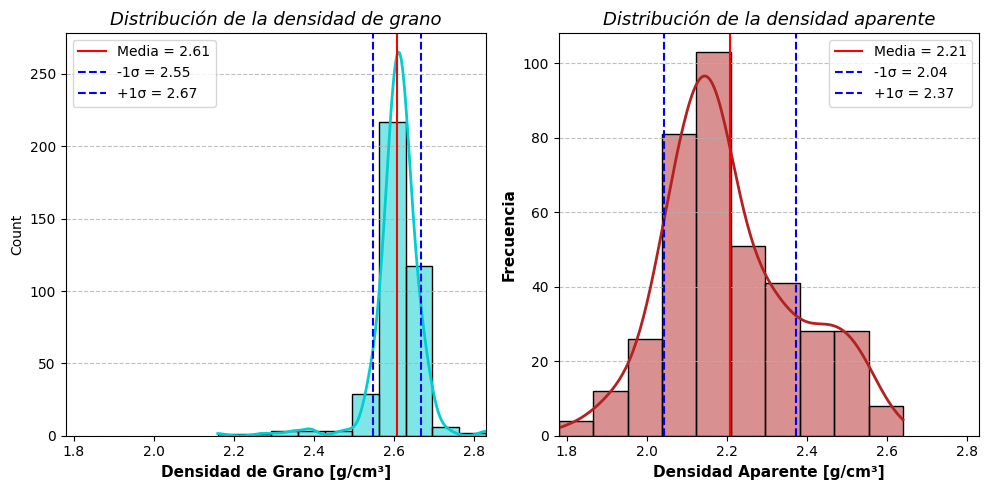

In [27]:
# Calcular estadísticas
mean_da = df['Densidad Aparente'].mean()
std_da  = df['Densidad Aparente'].std()

mean_dg = df['Densidad de Grano'].mean()
std_dg  = df['Densidad de Grano'].std()

# Definir una escala común en X para ambos histogramas
xmin = min(df['Densidad Aparente'].min(), df['Densidad de Grano'].min())
xmax = max(df['Densidad Aparente'].max(), df['Densidad de Grano'].max())

# Crear figure con dos subplots
plt.figure(figsize=(10, 5))

# ─────────── HISTOGRAMA 1 ───────────
plt.subplot(1, 2, 1)
sns.histplot(df['Densidad de Grano'], bins=10, kde=True,line_kws={'linestyle': '-', 'linewidth': 2}, color='darkturquoise', edgecolor='black', alpha=0.5)

plt.axvline(mean_dg, color='red', linestyle='-', linewidth=1.5, label=f"Media = {mean_dg:.2f}")
plt.axvline(mean_dg - std_dg, color='blue', linestyle='--', linewidth=1.5, label=f"-1σ = {mean_dg - std_dg:.2f}")
plt.axvline(mean_dg + std_dg, color='blue', linestyle='--', linewidth=1.5, label=f"+1σ = {mean_dg + std_dg:.2f}")

plt.xlim(xmin, xmax)
plt.title("Distribución de la densidad de grano", fontsize=13, fontstyle='italic')
plt.xlabel("Densidad de Grano [g/cm³]", fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.legend()

# ─────────── HISTOGRAMA 2 ───────────
plt.subplot(1, 2, 2)
sns.histplot(df['Densidad Aparente'], bins=10, kde=True,line_kws={'linestyle': '-', 'linewidth': 2}, color='firebrick', edgecolor='black', alpha=0.5)

# Líneas de media y desvío
plt.axvline(mean_da, color='red', linestyle='-', linewidth=1.5, label=f"Media = {mean_da:.2f}")
plt.axvline(mean_da - std_da, color='blue', linestyle='--', linewidth=1.5, label=f"-1σ = {mean_da - std_da:.2f}")
plt.axvline(mean_da + std_da, color='blue', linestyle='--', linewidth=1.5, label=f"+1σ = {mean_da + std_da:.2f}")

plt.xlim(xmin, xmax)
plt.title("Distribución de la densidad aparente", fontsize=13, fontstyle='italic')
plt.xlabel("Densidad Aparente [g/cm³]", fontsize=11, fontweight='bold')
plt.ylabel("Frecuencia", fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.legend()

plt.tight_layout()
plt.show()


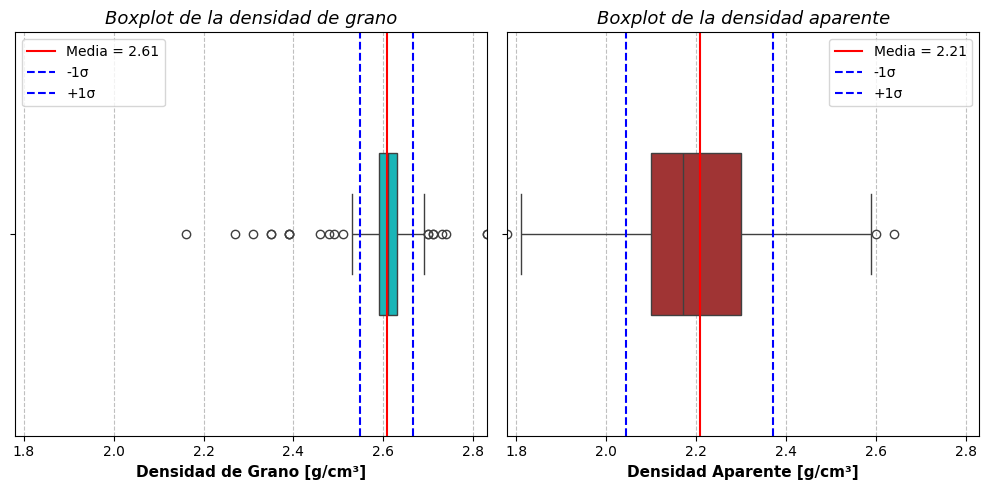

In [28]:
plt.figure(figsize=(10, 5))

# ─────────── BOXPLOT 1 ───────────
plt.subplot(1, 2, 1)
sns.boxplot(
    x=df['Densidad de Grano'],
    color='darkturquoise',
    width=0.4
)

# Líneas de media y desvío
plt.axvline(mean_dg, color='red', linestyle='-', linewidth=1.5, label=f"Media = {mean_dg:.2f}")
plt.axvline(mean_dg - std_dg, color='blue', linestyle='--', linewidth=1.5, label=f"-1σ")
plt.axvline(mean_dg + std_dg, color='blue', linestyle='--', linewidth=1.5, label=f"+1σ")

plt.xlim(xmin, xmax)
plt.title("Boxplot de la densidad de grano", fontsize=13, fontstyle='italic')
plt.xlabel("Densidad de Grano [g/cm³]", fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.legend()

# ─────────── BOXPLOT 2 ───────────
plt.subplot(1, 2, 2)
sns.boxplot(
    x=df['Densidad Aparente'],
    color='firebrick',
    width=0.4
)

# Líneas de media y desvío
plt.axvline(mean_da, color='red', linestyle='-', linewidth=1.5, label=f"Media = {mean_da:.2f}")
plt.axvline(mean_da - std_da, color='blue', linestyle='--', linewidth=1.5, label=f"-1σ")
plt.axvline(mean_da + std_da, color='blue', linestyle='--', linewidth=1.5, label=f"+1σ")

plt.xlim(xmin, xmax)
plt.title("Boxplot de la densidad aparente", fontsize=13, fontstyle='italic')
plt.xlabel("Densidad Aparente [g/cm³]", fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.legend()

plt.tight_layout()
plt.show()

La densidad de grano presenta un valor medio de 2.61 g/cm³, muy cercano al típico de areniscas con alto contenido de cuarzo (≈2.65 g/cm³). Su baja dispersión (STD = 0.06 g/cm³) evidencia una **composición mineralógica homogénea** a lo largo del dataset. Los valores outliers que puenden apreciarse en el boxplot pueden ser resultado de algunas muestras de otra composición o bien de fallas en la medición.

En contraste, la densidad aparente muestra un valor medio de 2.21 g/cm³, con un rango amplio que varía entre 1.78 y 2.64 g/cm³. Esta variabilidad podría asociarse a diferencias mineralógicas o a distintos grados de compactación. Sin embargo, dado que la densidad de grano indica una composición mineralógica consistente, es razonable atribuir esta amplitud en la densidad aparente principalmente a variaciones en la compactación y en consecuencia en el volumen poral de las muestras. Para verificar estas hipótesis, será necesario evaluar el comportamiento de ambas densidades en función de la profundidad y la porosidad, lo que permitirá determinar la influencia relativa del enterramiento y la estructura porosa en estas propiedades. Para esta otra variable, hay muy pocos valores outliers que se pueden atribuirse a errores en la medición.



## Porosidad y Permeabilidad

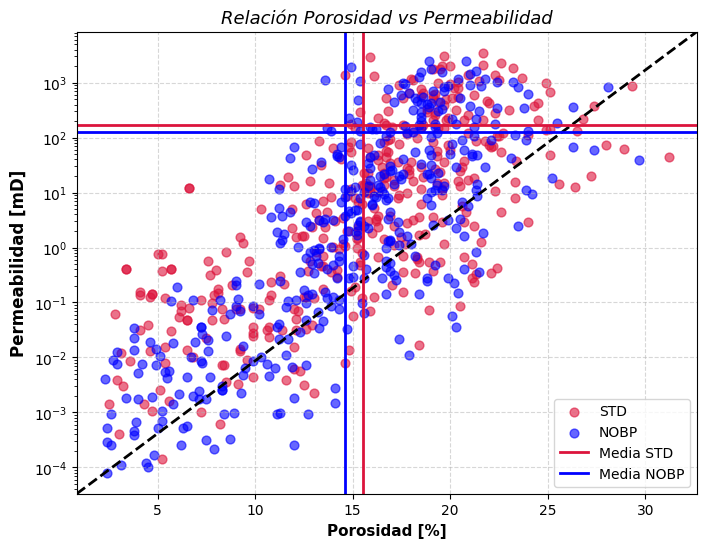

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(df['Porosidad STD'],
            df['Permeabilidad STD'],
            s=40,
            alpha=0.6,
            color='crimson',
            label='STD')
plt.scatter(df['Porosidad NOBP'],
            df['Permeabilidad NOBP'],
            s=40,
            alpha=0.6,
            color='blue',
            label = 'NOBP')

# ---- Línea 45° ----
ax = plt.gca()  # obtener el eje actual
ax.plot([0, 1], [0, 1], transform=ax.transAxes,
        linestyle='--', linewidth=2, color='black')

# --- Medias STD ---
mean_por_STD  = df['Porosidad STD'].mean()
mean_perm_STD = df['Permeabilidad STD'].mean()

# --- Medias NOBP ---
mean_por_NOBP  = df['Porosidad NOBP'].mean()
mean_perm_NOBP = df['Permeabilidad NOBP'].mean()

# --- Líneas verticales (Porosidad) ---
plt.axvline(mean_por_STD,  color='crimson', linestyle='-', linewidth=2,
            label='Media STD')

plt.axvline(mean_por_NOBP, color='blue', linestyle='-', linewidth=2,
            label='Media NOBP')

# --- Líneas horizontales (Permeabilidad) ---
plt.axhline(mean_perm_STD,  color='crimson', linestyle='-', linewidth=2)

plt.axhline(mean_perm_NOBP, color='blue', linestyle='-', linewidth=2)

plt.yscale('log')
plt.title("Relación Porosidad vs Permeabilidad", fontsize=13, fontstyle='italic')
plt.xlabel("Porosidad [%]", fontsize=11, fontweight='bold')
plt.ylabel("Permeabilidad [mD]", fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

La porosidad STD presenta un valor medio de 15.5%, mientras que la porosidad NOBP es ligeramente menor (14.6%). Esta diferencia es consistente con el efecto esperado de la presión de confinamiento: al aplicar condiciones no confinadas (NOBP), los poros permanecen menos comprimidos y, por lo tanto, la porosidad medida resulta ligeramente superior que bajo condiciones estándar de laboratorio.

Los rangos observados (entre 2% y 31%) y las desviaciones estándar cercanas a 5.6% evidencian una marcada heterogeneidad porosa, atribuible a variaciones en litología, grado de compactación y diagenesis entre las diferentes muestras.

La permeabilidad muestra una dispersión aún más pronunciada, con valores STD que van desde 0.00014 mD hasta 3500 mD. Las medias (167 mD STD y 129 mD NOBP) junto con las elevadas desviaciones estándar (entre 340 y 440 mD) indican una distribución fuertemente asimétrica, dominada por valores extremos característicos de sistemas con conectividad y geometrías de poros muy diversas.

Tal como ocurre con la porosidad, las mediciones de permeabilidad bajo condiciones NOBP tienden a dar resultados menores, reflejando la presión de confinamiento y la consecuente disminución de los canales de flujo.

En conjunto, la elevada heterogeneidad observada en porosidad y permeabilidad es coherente con el origen del dataset, que reúne muestras provenientes de distintas áreas y distintos reservorios, cada uno con características petrofísicas particulares.




## Profundidad y NOBP

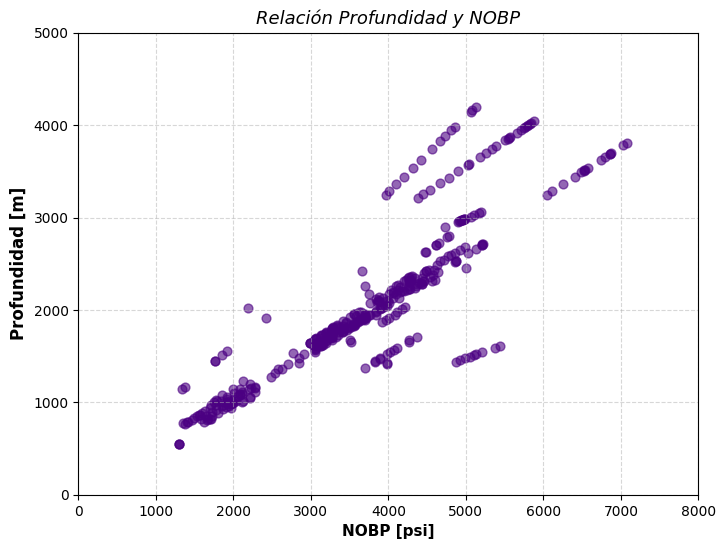

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(df['NOBP'],
            df['Profundidad'],
            s=40,
            alpha=0.6,
            color='indigo')

plt.title("Relación Profundidad y NOBP", fontsize=13, fontstyle='italic')
plt.xlabel("NOBP [psi]", fontsize=11, fontweight='bold')
plt.ylabel("Profundidad [m]", fontsize=12, fontweight='bold')
plt.xlim([0,8000])
plt.ylim([0,5000])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El rango de profundidades (548–4200 m) y de presiones NOBP (1294–7085 psi) indica que el dataset integra muestras provenientes de múltiples unidades estratigráficas y de condiciones de enterramiento muy distintas. Esta amplitud es coherente con la variabilidad previamente observada en densidad aparente, porosidad y permeabilidad.

Además, el gráfico muestra una correlación marcada entre la profundidad y la presión de confinamiento en reservorio, lo cual es esperable, ya que ambas variables aumentan sistemáticamente con la carga litostática. Esta relación confirma que el dataset combina información de pozos ubicados en distintos contextos geológicos y con diferentes gradientes de presión.



##**Conclusión preliminar**

El dataset presenta una alta variabilidad petrofísica, reflejo de un dataset heterogéneo tanto en propiedades de almacenamiento (porosidad) como de flujo (permeabilidad). La consistencia de la densidad de grano sugiere que la variabilidad se debe más a condiciones diagenéticas (geológicas) y de compactación que a cambios significativos en la composición mineralógica.

Las diferencias entre mediciones STD vs NOBP confirman el impacto esperado de la presión de confinamiento, lo que será importante al momento de entrenar modelos de predicción para asegurar representatividad respecto a condiciones de reservorio.

Se considera necesario tener en cuenta esta heterogeneidad al momento de analizar correlaciones entre parámetros. En caso de no obtener relaciones claras, será conveniente subdividir el dataset por zonas o unidades de reservorio. De esta forma, al trabajar con grupos de muestras de contextos geológicos más homogéneos, se reduce la dispersión natural de los datos y se favorece la construcción de modelos más robustos, tanto en los análisis como en el entrenamiento de modelos predictivos.

#Correlación

En esta siguiente etapa se evaluará la presencia y la intensidad de posibles correlaciones entre las distintas variables del dataset. Este análisis es fundamental para determinar qué parámetros pueden utilizarse como predictores al momento de construir los modelos, y hasta qué punto una variable puede explicar el comportamiento de las demás.

Para ello se calcularán los coeficientes de correlación de Pearson (relaciones lineales) y de Spearman (relaciones monotónicas no necesariamente lineales). A partir de estos resultados, se discutirán las conclusiones correspondientes y se analizarán gráficas específicas para comprender en mayor detalle cómo podrían integrarse estas relaciones en el desarrollo del modelo de aprendizaje supervisado.


##**Pearson**

El coeficiente de correlación de Pearson permite evaluar la relación lineal entre dos variables continuas. Mide qué tan bien una variable puede describirse como una función lineal de la otra. Sus valores van de –1 a +1, donde los extremos indican una asociación lineal perfecta (negativa o positiva) y valores cercanos a cero representan ausencia de relación lineal.

In [31]:
#Defino los parámetros a relacionar y empleo correlación de Pearson

columnas = ["Densidad Aparente", "Densidad de Grano", "Profundidad", "Porosidad STD", "Permeabilidad STD", "NOBP", "Porosidad NOBP", "Permeabilidad NOBP"]

correlacion_pearson = df[columnas].corr(method="pearson")

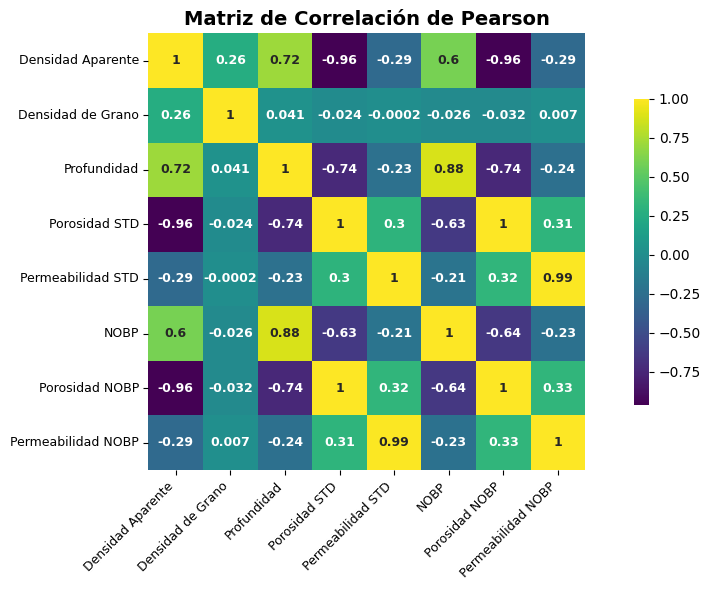

In [32]:
# Visualización de la matriz de correlación de Pearson

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlacion_pearson,
    annot=True,
    cmap="viridis",
    annot_kws={"size": 9, 'fontweight':'bold'},
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("Matriz de Correlación de Pearson", fontsize=14, fontweight="bold")

# Rotación de etiquetas
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


A continuación, se define un umbral de correlación que permitirá identificar y analizar de manera puntual las relaciones más relevantes entre las variables, facilitando su interpretación.

In [33]:
#Defino un umbral para analizar los resultados de la correlación

umbral_correlacion = 0.70

resultados = {}

for columna in correlacion_pearson.columns:
    correlaciones = correlacion_pearson[columna]
    seleccionadas = correlaciones[(correlaciones.abs() > umbral_correlacion) & (correlaciones.index != columna)].index.tolist()
    resultados[columna] = seleccionadas

print("\n=== Correlaciones |r_p| > 0.70 usando Pearson ===")

for col, lista in resultados.items():
    print(f"\nVariables con correlación respecto a '{col}':")
    if lista:
        for v in lista:
            print("  -", v)
    else:
        print("  (Ninguna)")


=== Correlaciones |r_p| > 0.70 usando Pearson ===

Variables con correlación respecto a 'Densidad Aparente':
  - Profundidad
  - Porosidad STD
  - Porosidad NOBP

Variables con correlación respecto a 'Densidad de Grano':
  (Ninguna)

Variables con correlación respecto a 'Profundidad':
  - Densidad Aparente
  - Porosidad STD
  - NOBP
  - Porosidad NOBP

Variables con correlación respecto a 'Porosidad STD':
  - Densidad Aparente
  - Profundidad
  - Porosidad NOBP

Variables con correlación respecto a 'Permeabilidad STD':
  - Permeabilidad NOBP

Variables con correlación respecto a 'NOBP':
  - Profundidad

Variables con correlación respecto a 'Porosidad NOBP':
  - Densidad Aparente
  - Profundidad
  - Porosidad STD

Variables con correlación respecto a 'Permeabilidad NOBP':
  - Permeabilidad STD


La matriz de correlación confirma gran parte de las tendencias que ya habíamos identificado, pero también aporta nuevos elementos clave para definir qué variables serán útiles para el modelado y cuáles no aportan información relevante.

La siguiente tabla resume las correlaciones más significativas del análisis de Pearson, clasificando la intensidad de cada relación, su interpretación petrofísica y su relevancia para la construcción de modelos predictivos.

<div style="font-size:20px">

| Variables correlacionadas                    | r (Pearson)       | Tipo de relación  | Interpretación petrofísica                                                                                   | Relevancia para el modelado                                         |
| -------------------------------------------- | ----------------- | ----------------- | ------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------- |
| **Porosidad STD – Porosidad NOBP**           | **1.00**          | Perfecta          | Ambas variables contienen la misma información. Una es versión confinada de la otra.                         | **Redundante.** Conservar solo una para evitar colinealidad.        |
| **Permeabilidad STD – Permeabilidad NOBP**   | **0.99**          | Muy fuerte        | Ambas mediciones representan el mismo parámetro. Una es versión confinada de la otra.                        | **Redundante.** Conservar solo una para evitar colinealidad.        |
| **Profundidad – NOBP**                       | **0.88**          | Fuerte positiva   | A mayor profundidad, mayor presión de confinamiento, consistente con gradientes geológicos.                  | **Muy relevante.** Profundidad puede predecir NOBP.                 |
| **Densidad Aparente – Porosidad (STD/NOBP)** | **–0.96**         | Fuerte negativa   | A mayor densidad aparente, menor volumen de poros. Relación física esperada.                                 | **Muy útil** como predictor sustituto de porosidad.                 |
| **Profundidad – Porosidad (STD/NOBP)**       | **–0.74**         | Fuerte negativa   | La porosidad disminuye con la compactación a mayor profundidad.                                              | **Relevante.** Permite modelar porosidad en función de profundidad. |
| **NOBP – Porosidad (STD/NOBP)**              | **–0.63 / –0.64** | Moderada negativa | A mayor presión de confinamiento, menor porosidad.                                                           | **Utilidad moderada.** Complementa a profundidad.                   |
| **Profundidad – Densidad Aparente**          | **0.71**          | Fuerte positiva   | La densidad aumenta con la compactación al incrementar la profundidad.                                       | **Relevante.** Sirve para estimar grado de compactación.            |
| **Porosidad – Permeabilidad**                | **0.30 / 0.31**   | Débil             | Tendencia general, pero fuerte dispersión debido a heterogeneidad litológica.                                | **Baja utilidad.** Requiere modelos no lineales.                    |
| **Profundidad – Permeabilidad**              | **–0.23 / –0.24** | Débil             | Ligera tendencia a permeabilidad menor con mayor profundidad, pero no determinante.                          | **Poca relevancia** como predictor directo.                         |
| **Densidad de grano – resto de variables**   | **≈ 0**           | Inexistente       | La densidad de grano es estable y no depende de condiciones de enterramiento ni propiedades petrofísicas.    | **No relevante** para el modelado.                                  |

</div>


##**Spearman**

El coeficiente de Spearman evalúa la relación monotónica entre dos variables, independientemente de si dicha relación es lineal. Se basa en los rangos de los valores y no en los valores absolutos, por lo que es menos sensible a valores atípicos y a distribuciones no normales. También toma valores entre –1 y +1, indicando correlación monotónica perfecta cuando los rangos se alinean de manera creciente o decreciente. Spearman resulta especialmente apropiado cuando se sospecha de relaciones no lineales o cuando los datos presentan alta dispersión.

In [34]:
# Calcula con la correlación de Spearman utilizando los mismos parámetros

correlacion_spearman = df[columnas].corr(method='spearman')

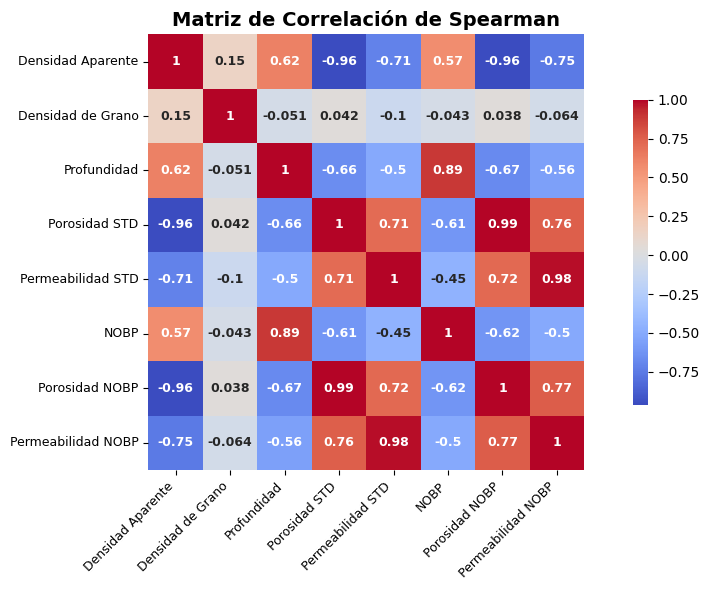

In [35]:
# Visualización de la matriz de correlación de Spearman

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlacion_spearman,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size": 9, 'fontweight':'bold'},
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.title("Matriz de Correlación de Spearman", fontsize=14, fontweight="bold")

# Rotación de etiquetas
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [36]:
#Defino un umbral para analizar los resultados de la correlación

umbral_correlacion = 0.70

resultados_spearman = {}

for columna in correlacion_spearman.columns:
    correlaciones = correlacion_spearman[columna]
    seleccionadas = correlaciones[
        (correlaciones.abs() > umbral_correlacion) &
        (correlaciones.index != columna)
    ].index.tolist()

    resultados_spearman[columna] = seleccionadas

print("\n=== Correlaciones |r_s| > 0.70 usando Spearman ===")

for col, lista in resultados_spearman.items():
    print(f"\nVariables correlacionadas con '{col}':")
    if lista:
        for v in lista:
            print(f"  - {v}")
    else:
        print("  (Ninguna)")


=== Correlaciones |r_s| > 0.70 usando Spearman ===

Variables correlacionadas con 'Densidad Aparente':
  - Porosidad STD
  - Permeabilidad STD
  - Porosidad NOBP
  - Permeabilidad NOBP

Variables correlacionadas con 'Densidad de Grano':
  (Ninguna)

Variables correlacionadas con 'Profundidad':
  - NOBP

Variables correlacionadas con 'Porosidad STD':
  - Densidad Aparente
  - Permeabilidad STD
  - Porosidad NOBP
  - Permeabilidad NOBP

Variables correlacionadas con 'Permeabilidad STD':
  - Densidad Aparente
  - Porosidad STD
  - Porosidad NOBP
  - Permeabilidad NOBP

Variables correlacionadas con 'NOBP':
  - Profundidad

Variables correlacionadas con 'Porosidad NOBP':
  - Densidad Aparente
  - Porosidad STD
  - Permeabilidad STD
  - Permeabilidad NOBP

Variables correlacionadas con 'Permeabilidad NOBP':
  - Densidad Aparente
  - Porosidad STD
  - Permeabilidad STD
  - Porosidad NOBP


La siguiente tabla resume las correlaciones más significativas del análisis de Spearman, clasificando la intensidad de cada relación, su interpretación petrofísica y su relevancia para la construcción de modelos predictivos.

| Variables correlacionadas                    | r (Spearman)     | Tipo de relación     | Interpretación petrofísica                                                                                 | Relevancia para el modelado                                         |
| -------------------------------------------- | ----------------- | -------------------- | ---------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| **Porosidad STD – Porosidad NOBP**           | **0.99**          | Casi perfecta        | Ambas variables representan exactamente el mismo orden de valores.                                         | **Redundante.** Conservar solo una.                                |
| **Permeabilidad STD – Permeabilidad NOBP**   | **0.98**          | Casi perfecta        | Mismo parámetro bajo condiciones distintas; comportamiento monótono idéntico.                              | **Redundantes.** Seleccionar solo una.                             |
| **Profundidad – NOBP**                       | **0.89**          | Fuerte positiva      | A mayor profundidad, mayor presión de sobrecarga; tendencia monótona muy clara.                             | **Muy relevante.** Predictor directo de NOBP.                       |
| **Densidad Aparente – Porosidad (STD/NOBP)** | **–0.95 / –0.96** | Fuerte negativa      | Las muestras con mayor compactación tienen menor porosidad.                                                 | **Muy útil.** Puede sustituir mediciones directas de porosidad.     |
| **Profundidad – Porosidad (STD/NOBP)**       | **–0.66 / –0.67** | Moderada negativa | La compactación con la profundidad reduce el volumen de poros en forma monótona.                            | **Relevante.** Predictora indirecta de porosidad.                   |
| **Porosidad – Permeabilidad**                | **0.71 / 0.76**   | Fuerte positiva      | La permeabilidad aumenta con la porosidad, relación no lineal pero monótona                | **Importante.** Fundamental para modelos petrofísicos.              |
| **Profundidad – Densidad Aparente**          | **0.62**          | Moderada positiva    | Muestras más profundas suelen estar más compactadas → mayor densidad aparente.                              | **Útil.** Ayuda a estimar compactación y calidad de roca.           |
| **Profundidad – Permeabilidad**              | **–0.50 / –0.56** | Moderada negativa    | A mayor profundidad, menor permeabilidad por compactación, aunque con dispersión considerable.              | **Relevancia media.** Puede complementar modelos.                   |
| **NOBP – Porosidad (STD/NOBP)**              | **–0.61 / –0.62** | Moderada negativa    | A mayor presión de confinamiento, menor porosidad, consistente con deformación de poros.                    | **Moderada utilidad** como predictor adicional.                     |
| **Densidad de grano – resto de variables**   | **≈ 0**           | Inexistente          | Mineralogía homogénea; no aporta información predictiva.                                                    | **No relevante** para el modelado.                                  |


##**Information Gain**

Para complementar el análisis de correlación lineal y monótona, se emplea la métrica de Information Gain (IG), la cual permite cuantificar cuánta información aporta cada variable predictora a la explicación de una variable objetivo. A diferencia de Pearson o Spearman, Information Gain no asume relaciones lineales ni monotónicas, sino que se basa en la reducción de la entropía del sistema: una variable es más relevante cuanto mayor es la disminución de incertidumbre que produce sobre el target.

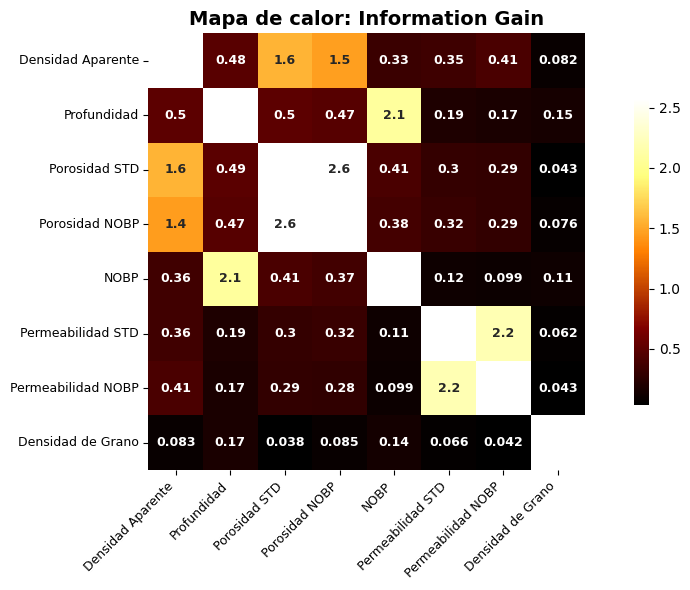

In [37]:
#Defino las variables a estudiar

variables = [
    "Densidad Aparente",
    "Profundidad",
    "Porosidad STD",
    "Porosidad NOBP",
    "NOBP",
    "Permeabilidad STD",
    "Permeabilidad NOBP",
    "Densidad de Grano"
]

# Crear matriz vacía para guardar el Information Gain
ig_matrix = pd.DataFrame(index=variables, columns=variables)

# Calcular IG para cada par (X -> Y)
for target in variables:                 # Y
    y = df[target].values
    for feature in variables:            # X
        X = df[[feature]].values

        if feature == target:
            ig_matrix.loc[feature, target] = np.nan   # no se calcula sobre sí misma
        else:
            ig = mutual_info_regression(X, y, random_state=42)
            ig_matrix.loc[feature, target] = ig[0]

# Convertir a float
ig_matrix = ig_matrix.astype(float)

plt.figure(figsize=(10, 6))

sns.heatmap(
    ig_matrix,
    cmap="afmhot",
    annot=True,
    annot_kws={"size": 9, 'fontweight':'bold'},
    square=True,
    cbar_kws={"shrink": 0.7}
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Mapa de calor: Information Gain", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

El análisis de correlación basado en Information Gain no aporta información adicional relevante respecto de la obtenida previamente mediante los coeficientes de Pearson y Spearman. Las variables que resultan más informativas coinciden con aquellas que ya habían sido identificadas como altamente correlacionadas en los análisis anteriores, confirmando que las principales dependencias del dataset son esencialmente lineales o monótonas. En consecuencia, este enfoque refuerza las conclusiones previas, pero no introduce nuevas relaciones significativas entre los parámetros evaluados.

##Comparativa final y correlaciones

Los gráficos interactivos que se presentan a continuación fueron construidos con el objetivo de visualizar de manera gráfica las correlaciones previamente identificadas mediante los coeficientes de Pearson y Spearman. A través de estos gráficos se busca analizar la forma y el comportamiento de dichas relaciones,y, a partir de ello, definir adecuadamente las variables objetivo (target) y las variables predictoras.

In [38]:
# Lista de variables (etiqueta -> nombre de columna)
variables = {
    "Densidad Aparente": "Densidad Aparente",
    "Densidad de Grano": "Densidad de Grano",
    "Profundidad": "Profundidad",
    "Porosidad STD": "Porosidad STD",
    "Permeabilidad STD": "Permeabilidad STD",
    "NOBP": "NOBP",
    "Porosidad NOBP": "Porosidad NOBP",
    "Permeabilidad NOBP": "Permeabilidad NOBP"
}

In [39]:
# Colores (suficientes para hasta 8 gráficos)
color_palette = ['crimson', 'royalblue', 'darkgreen', 'darkorange', 'purple', 'teal', 'brown', 'magenta']

def plot_relaciones(x_var):
    # Column name para X
    xcol = variables[x_var]

    # Construir lista de Y (todas excepto X) y que existan en df
    y_cols = [v for v in variables.values() if v != xcol and v in df.columns]

    if xcol not in df.columns:
        print(f"Columna seleccionada ({xcol}) no existe en el DataFrame.")
        return

    n = len(y_cols)
    if n == 0:
        print("No hay otras variables para graficar contra la seleccionada.")
        return

    # Grilla de subplots
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

    # Lista plana de ejes
    axes_list = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, (ycol, ax, color) in enumerate(zip(y_cols, axes_list, color_palette)):

        xdata = df[xcol]
        ydata = df[ycol]

        mask = xdata.notna() & ydata.notna()

        # --- FILTRADO ESPECIAL PARA LOG(X) ---
        if xcol in ['Permeabilidad STD', 'Permeabilidad NOBP']:
            mask = mask & (xdata > 0)

        # --- FILTRADO ESPECIAL PARA LOG(Y) ---
        if ycol in ['Permeabilidad STD', 'Permeabilidad NOBP']:
            mask = mask & (ydata > 0)

        ax.scatter(xdata[mask], ydata[mask], s=40, alpha=0.7, color=color)

        ax.set_xlabel(f"{xcol}", fontsize=8, fontweight='bold')
        ax.set_ylabel(f"{ycol}", fontsize=8, fontweight='bold')
        ax.set_title(f"{xcol} vs {ycol}", fontsize=9, fontstyle='italic')
        ax.grid(True, linestyle='--', alpha=0.5)

        # ---- ESCALA LOGARÍTMICA EN EJE X SI ES PERMEABILIDAD ----
        if xcol in ['Permeabilidad STD', 'Permeabilidad NOBP']:
            ax.set_xscale('log')

        # ---- ESCALA LOGARÍTMICA EN EJE Y SI ES PERMEABILIDAD ----
        if ycol in ['Permeabilidad STD', 'Permeabilidad NOBP']:
            ax.set_yscale('log')

    # Ocultar subplots vacíos
    for j in range(len(y_cols), len(axes_list)):
        axes_list[j].axis('off')

    plt.tight_layout()
    plt.show()

# Widget interactivo
interact(
    plot_relaciones,
    x_var=Dropdown(options=list(variables.keys()), description="Variable X:")
)

interactive(children=(Dropdown(description='Variable X:', options=('Densidad Aparente', 'Densidad de Grano', '…

<function __main__.plot_relaciones(x_var)>

In [40]:
# Widgets de selección de variables
x_widget = widgets.Dropdown(
    options=list(variables.keys()),
    description="Eje X:",
    value="Porosidad STD"
)

y_widget = widgets.Dropdown(
    options=list(variables.keys()),
    description="Eje Y:",
    value="Permeabilidad STD"
)

# Widget para elegir variable de filtrado
filter_var_widget = widgets.Dropdown(
    options=list(variables.keys()),
    description="Filtrar por:",
    value="Porosidad STD"
)

# Slider — sus valores se actualizan automáticamente
range_slider = widgets.FloatRangeSlider(
    description="Rango:",
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="600px")
)

# Output
out = widgets.Output()

# ------------------------------------------
# FUNCIÓN QUE ACTUALIZA EL SLIDER
# ------------------------------------------
def update_slider(*args):
    col = variables[filter_var_widget.value]
    min_val = float(df[col].min())
    max_val = float(df[col].max())

    range_slider.min = min_val
    range_slider.max = max_val
    range_slider.value = (min_val, max_val)
    range_slider.step = (max_val - min_val) / 200

update_slider()
filter_var_widget.observe(update_slider, "value")

# ------------------------------------------
# FUNCIÓN PARA ACTUALIZAR EL GRÁFICO
# ------------------------------------------
def actualizar_grafico(*args):
    with out:
        clear_output(wait=True)

        col_x = variables[x_widget.value]
        col_y = variables[y_widget.value]
        col_f = variables[filter_var_widget.value]

        min_f, max_f = range_slider.value

        df_f = df[(df[col_f] >= min_f) & (df[col_f] <= max_f)]

        # ---- GRAFICO ----
        plt.figure(figsize=(8,6))
        plt.scatter(df_f[col_x], df_f[col_y], color="teal", alpha=0.7)

        # Ejes y etiquetas
        plt.xlabel(col_x, fontsize=12, fontweight='bold')
        plt.ylabel(col_y, fontsize=12, fontweight='bold')

        # Escala log automática para permeabilidades
        if "Permeabilidad" in col_x:
            plt.xscale("log")
        if "Permeabilidad" in col_y:
            plt.yscale("log")

        plt.grid(True, linestyle='--', alpha=0.5)
        plt.title(f"{col_y} vs {col_x}\nFiltro: {col_f} entre {min_f:.2f} y {max_f:.2f}",
                  fontsize=13, fontstyle='italic')

        plt.show()

# Observers
x_widget.observe(actualizar_grafico, "value")
y_widget.observe(actualizar_grafico, "value")
filter_var_widget.observe(actualizar_grafico, "value")
range_slider.observe(actualizar_grafico, "value")

# Mostrar interfaz
ui = VBox([
    HBox([x_widget, y_widget]),
    HBox([filter_var_widget]),
    range_slider,
    out
])

display(ui)
actualizar_grafico()


A partir de los análisis de Pearson y Spearman, y de las gráficas realizadas se observa que:

*Profundidad y Densidad Aparente* actúan como drivers físicos primarios:
* Son fáciles de obtener.
* No son redundantes.
* Controlan indirectamente porosidad, permeabilidad y NOBP.

En cambio, *Porosidad, Permeabilidad y NOBP* son variables:
* Más costosas de medir.
* De mayor interés ingenieril.
* Claramente correlacionadas con las anteriores.

Conviene usarlas como variables objetivo (target) y no como inputs principales.

De todo el análisis, se concluye que la profundidad y la densidad aparente constituyen las variables predictoras más robustas del dataset, actuando como controladores físicos primarios del sistema. En este contexto, las porosidades, permeabilidades y la presión de confinamiento (NOBP) resultan candidatas naturales a ser utilizadas como variables objetivo, dado su alto interés ingenieril y su fuerte dependencia de las propiedades estructurales del medio.

Los resultados sugieren que es posible construir modelos predictivos confiables para porosidad y NOBP utilizando únicamente profundidad y densidad aparente, mientras que la predicción de permeabilidad se beneficia significativamente de la incorporación de la porosidad como variable intermedia, en un esquema de modelado en cascada.

# Modelado: Aprendizaje Supervisado

El problema abordado en este trabajo se enmarca dentro del aprendizaje supervisado, ya que se dispone de un conjunto de datos históricos donde las variables objetivo (porosidad, permeabilidad y presión de confinamiento -NOBP-) se encuentran medidas experimentalmente junto con sus variables explicativas (profundidad, densidad aparente, entre otras). Esto permite entrenar modelos capaces de aprender relaciones entre entradas y salidas conocidas, para luego generalizar y realizar predicciones sobre nuevos datos no observados.

El objetivo principal es construir modelos predictivos que permitan estimar propiedades petrofísicas relevantes a partir de variables más simples o más fácilmente medibles, lo cual es una problemática típica y adecuada para enfoques supervisados.


##**Modelado en Cadena**


Se opta por un enfoque de *modelos en cadena (chained models)* debido a la fuerte dependencia física y estadística entre las propiedades petrofísicas analizadas. Variables como la porosidad y la permeabilidad no dependen únicamente de la profundidad o la densidad aparente, sino también de otras propiedades intermedias, como la presión de confinamiento (NOBP) o la propia porosidad estimada previamente. A continuación, se muestra un diagrama de flujo de cómo será la construcción del modelo global.

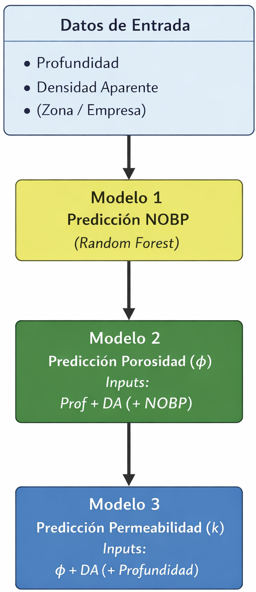

Este enfoque:

* Respeta la física del reservorio
* Reduce incertidumbre
* Es escalable
* Es defendible ante cualquier revisor técnico

##**Algoritmo de Random Forest**

El algoritmo Random Forest fue seleccionado como modelo base debido a varias ventajas clave para el análisis y modelado de propiedades petrofísicas:

* Es capaz de capturar relaciones no lineales y complejas entre variables, lo cual resulta fundamental en este conjunto de datos. A partir del análisis de correlación de Pearson y Spearman se observa que, salvo el vínculo entre profundidad y NOBP, la mayoría de las relaciones no presentan un comportamiento lineal fuerte, lo que justifica el uso de modelos no paramétricos.

* Presenta una alta robustez frente a outliers y ruido, característica especialmente relevante en datos petrofísicos provenientes de distintos pozos, zonas y reservorios, donde la heterogeneidad es significativa.

* Permite evaluar la importancia relativa de las variables predictoras, aportando información adicional valiosa para la interpretación física del modelo y para la toma de decisiones en la selección de variables.

##**Selección de Datos "Train" y "Test": GroupKFold y validación cruzada**

En las etapas iniciales del modelado, la separación de los conjuntos de entrenamiento y prueba se realizó de forma secuencial, utilizando las últimas observaciones del dataset como conjunto de validación. Si bien este enfoque resulta simple y útil para una primera evaluación del desempeño de los modelos, presenta una limitación importante, estos registros pueden corresponder a un pozo o zona específica sesgando la evaluación. Más aún, de ampliar el dataset, esta segmentación de datos de entrenamiento y validación acota aún más la calidad de los resultados.

Con el objetivo de obtener una evaluación más robusta y realista, se adopta el esquema de validación GroupKFold, utilizando el identificador de pozo como variable de agrupamiento. Este enfoque garantiza que todas las muestras de un mismo pozo queden exclusivamente en el conjunto de entrenamiento o en el de validación, evitando que el modelo sea entrenado y evaluado sobre datos geológicamente correlacionados.

Al utilizar GroupKFold se implementa un esquema de validación cruzada, en el cual el modelo es entrenado y evaluado de manera iterativa sobre múltiples particiones del conjunto de datos. En cada fold, un subconjunto de pozos es reservado exclusivamente para validación, mientras que el resto se utiliza para el entrenamiento del modelo, calculándose las métricas de desempeño de forma independiente. Este procedimiento permite analizar la estabilidad del modelo frente a diferentes configuraciones de datos, reducir la dependencia de una única partición y obtener una estimación más confiable y representativa de su capacidad de generalización a nuevos pozos.

##**Análisis de Residuos**

En cada paso del modelado, se realizará un análisis de residuos. Consiste en estudiar las diferencias entre los valores observados y los valores predichos por un modelo. Estos residuos representan el error del modelo y permiten evaluar no solo su desempeño global, sino también su comportamiento local a lo largo del rango de datos.

El objetivo principal del análisis de residuos es identificar patrones sistemáticos en los errores que no son capturados por las métricas globales (como R², MAE o RMSE). Un modelo bien ajustado debería presentar residuos distribuidos de manera aleatoria alrededor de cero, sin tendencias claras ni dependencia con el valor de la variable real o predicha. Este análisis es especialmente útil para detectar sesgos, heterocedasticidad, problemas de escala, errores estructurales del modelo y zonas del dominio donde las predicciones pierden confiabilidad.

In [41]:
#Función para calcular el residuo

def calcular_residuos(y_real, y_pred, tipo="relativo"):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    if tipo == "relativo":
        residuo = (y_pred - y_real) / y_real

    elif tipo == "log":
        residuo = np.log10(y_pred) - np.log10(y_real)

    else:
        raise ValueError("tipo debe ser 'relativo' o 'log'")

    return residuo

In [42]:
#Función para graficar los residuos

def graficos_residuos(y_real, y_pred, titulo, tipo="relativo"):

    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    residuo = calcular_residuos(y_real, y_pred, tipo=tipo)

    mask_fuera = np.abs(residuo) >= 0.25
    mask_dentro = np.abs(residuo) < 0.25

    fig, axes = plt.subplots(1, 2, figsize=(9, 5))

    # --- Residuos vs valor real ---
    axes[0].scatter(
        y_real[mask_dentro],
        residuo[mask_dentro],
        color='red',
        alpha=0.6,
        label='|residuo| < umbral'
    )

    axes[0].scatter(
        y_real[mask_fuera],
        residuo[mask_fuera],
        color='darkorange',
        alpha=0.6,
        label='|residuo| ≥ umbral'
    )

    axes[0].axhline(0, color='k', linestyle='--', linewidth=1)

    if tipo == "relativo":
        axes[0].axhline(0.25, color='k', linestyle=':', linewidth=1)
        axes[0].axhline(-0.25, color='k', linestyle=':', linewidth=1)
        axes[0].set_ylabel("Residuo relativo")
        axes[0].set_ylim([-1, 1])

    else:  # log
        axes[0].axhline(0.3, color='k', linestyle=':', linewidth=1)
        axes[0].axhline(-0.3, color='k', linestyle=':', linewidth=1)
        axes[0].set_ylabel("Residuo log10(k)")
        axes[0].set_ylim([-4, 4])
        axes[0].set_xscale("log")

    axes[0].set_xlabel("Valor real")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # --- Histograma ---
    axes[1].hist(residuo, bins=30, density=True, color='green', alpha=0.6, edgecolor='black')
    axes[1].set_xlabel(axes[0].get_ylabel())
    axes[1].set_ylabel("Frecuencia")
    axes[1].grid(True, alpha=0.4)

    if tipo == "relativo":
        axes[1].set_xlim([-1, 1])
    else:
        axes[1].set_xlim([-4,4])

    kde = gaussian_kde(residuo)
    x_vals = np.linspace(residuo.min(), residuo.max(), 500)
    axes[1].plot(x_vals, kde(x_vals), color='blue', linewidth=1)

    plt.suptitle(titulo, fontstyle='italic')
    plt.tight_layout()
    plt.show()

A continuación, se realizarán y evaluarán los modelos.

##Modelo 1: Predicción de NOBP

In [43]:
# Definición de features y target para el modelo 1

features_m1 = [
    "Profundidad",
    "Densidad Aparente",
]

target_m1 = "NOBP"
groups = df["Pozo"]   # Separación de datos de train y test por Pozo

In [44]:
# GROUP K-FOLD (Train y Test)

gkf = GroupKFold(n_splits=5)

r2_scores = []
mae_scores = []
rmse_scores = []

y_real_all_1 = []
y_pred_all_1 = []
pozo_all_1 = []

In [45]:
#Entrenamiento y predicción del modelo 1

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    model_nobp.fit(df_train[features_m1], df_train[target_m1])
    y_test = df_test[target_m1]
    y_pred = model_nobp.predict(df_test[features_m1])

    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

    y_real_all_1.extend(y_test)
    y_pred_all_1.extend(y_pred)
    pozo_all_1.extend(df.iloc[test_idx]["Pozo"].values)

    print(f"\n===== FOLD {fold} =====")
    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R²   : {r2:.3f}")
    print(f"MAE  : {mae:.2f} psi")
    print(f"RMSE : {rmse:.2f} psi")


===== FOLD 1 =====
Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R²   : 0.839
MAE  : 304.99 psi
RMSE : 429.66 psi

===== FOLD 2 =====
Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R²   : 0.726
MAE  : 365.23 psi
RMSE : 516.34 psi

===== FOLD 3 =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R²   : -0.211
MAE  : 639.27 psi
RMSE : 948.53 psi

===== FOLD 4 =====
Pozos en test: ['PZ-1569' 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)']
R²   : 0.839
MAE  : 321.17 psi
RMSE : 630.53 psi

===== FOLD 5 =====
Pozos en test: ['EG-722' 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdCh.s-1902'
 'AdLas-1922' 'LACh-39(h)']
R²   : 0.820
MAE  : 409.70 psi
RMSE : 637.01 psi


In [46]:
# Métricas del modelo 1

print("\n===== MODELO 1 — RESULTADOS FINALES (GroupKFold) =====")
print(f"R²   : {r2_score(y_real_all_1, y_pred_all_1):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_1, y_pred_all_1):.2f} psi")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_1, y_pred_all_1)):.2f} psi")


===== MODELO 1 — RESULTADOS FINALES (GroupKFold) =====
R²   : 0.735
MAE  : 409.17 psi
RMSE : 658.52 psi


In [47]:
#Importancia de las variables en el modelo 1

importances_m1 = pd.DataFrame({
    "Variable": features_m1,
    "Importancia": model_nobp.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 1) =====")
display(importances_m1)


===== IMPORTANCIA DE VARIABLES (MODELO 1) =====


,Variable,Importancia
0,Profundidad,0.93982
1,Densidad Aparente,0.06018


In [48]:
#Armo un df con los resultados identificando los pozos. Para identificar aquellos fuera del rango de MAE

mae_m1 = mean_absolute_error(y_real_all_1, y_pred_all_1)
rmse_m1 = np.sqrt(mean_squared_error(y_real_all_1, y_pred_all_1))

df_m1 = pd.DataFrame({
    "Pozo": pozo_all_1,
    "y_real": y_real_all_1,
    "y_pred": y_pred_all_1
})

df_m1["fuera_MAE"] = (
    np.abs(df_m1["y_pred"] - df_m1["y_real"]) > mae_m1)
df_fuera_mae = df_m1[df_m1["fuera_MAE"]]

df_m1["fuera_RMSE"] = (
    np.abs(df_m1["y_pred"] - df_m1["y_real"]) > rmse_m1)
df_fuera_rmse = df_m1[df_m1["fuera_RMSE"]]

print("Pozos fuera del rango MAE: ", df_fuera_mae["Pozo"].unique())
print("Pozos fuera del rango RMSE: ", df_fuera_rmse["Pozo"].unique())

Pozos fuera del rango MAE:  ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PE-1071' 'PCG-1328' 'CS-2297'
 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925' 'LA.s-299'
 'PE-998' 'PCG-1302' 'LAJE.s-902' 'BdC-x-1' 'PVH-1374' 'RN-e.2102'
 'Myburg-752-792' 'AdCh.s-1902']
Pozos fuera del rango RMSE:  ['Lcav-133(h)' 'PCG-1328' 'PCG-1303' 'PR-1245' 'RN.a-2103' 'LA.s-299'
 'PCG-1302' 'LAJE.s-902' 'BdC-x-1' 'RN-e.2102' 'Myburg-752-792']


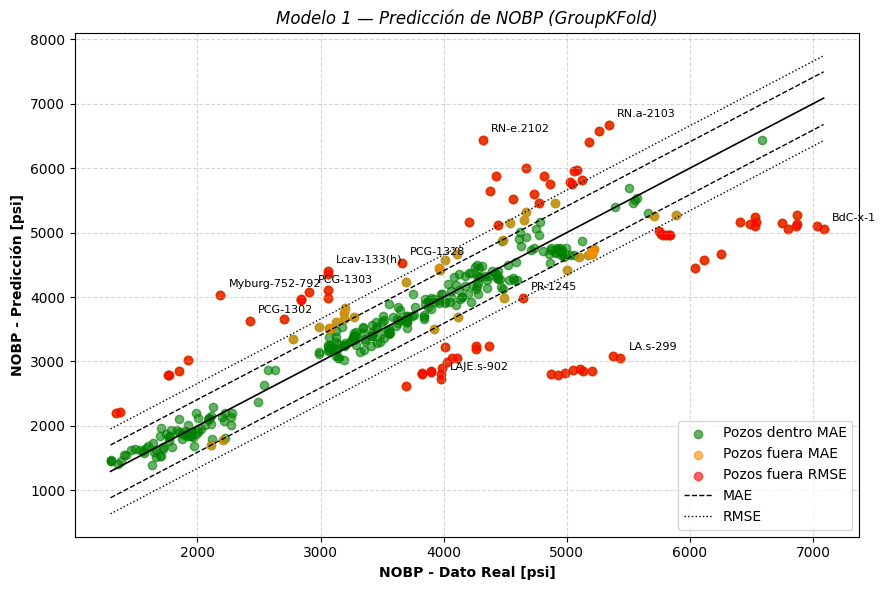

In [49]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
plt.scatter(df_m1["y_real"],df_m1["y_pred"],color="green",alpha=0.6,label="Pozos dentro MAE")
plt.scatter(df_fuera_mae["y_real"],df_fuera_mae["y_pred"],color="darkorange",alpha = 0.6,label="Pozos fuera MAE")
plt.scatter(df_fuera_rmse["y_real"],df_fuera_rmse["y_pred"],color="red",alpha = 0.6,label="Pozos fuera RMSE")

lims = [
    min(min(y_real_all_1), min(y_pred_all_1)),
    max(max(y_real_all_1), max(y_pred_all_1))
]
plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l + mae_m1 for l in lims], 'k--', label="MAE", linewidth=1)
plt.plot(lims, [l - mae_m1 for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l + rmse_m1 for l in lims], 'k:', label="RMSE", linewidth=1)
plt.plot(lims, [l - rmse_m1 for l in lims], 'k:', linewidth=1)

# Busco de los pozos fuera del RMSE, el punto más lejano para etiquetar
df_out = df_m1[df_m1["fuera_RMSE"]].copy()
df_out["dist_11"] = (df_out["y_real"] - df_out["y_pred"]).abs()
df_labels = df_out.loc[
    df_out.groupby("Pozo")["dist_11"].idxmax()
]

# Agregar etiquetas
for _, row in df_labels.iterrows():
    plt.annotate(
        row["Pozo"],
        (row["y_real"], row["y_pred"]),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=8,
        color="black"
    )

plt.xlabel("NOBP - Dato Real [psi]", fontweight='bold')
plt.ylabel("NOBP - Predicción [psi]", fontweight='bold')
plt.title("Modelo 1 — Predicción de NOBP (GroupKFold)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

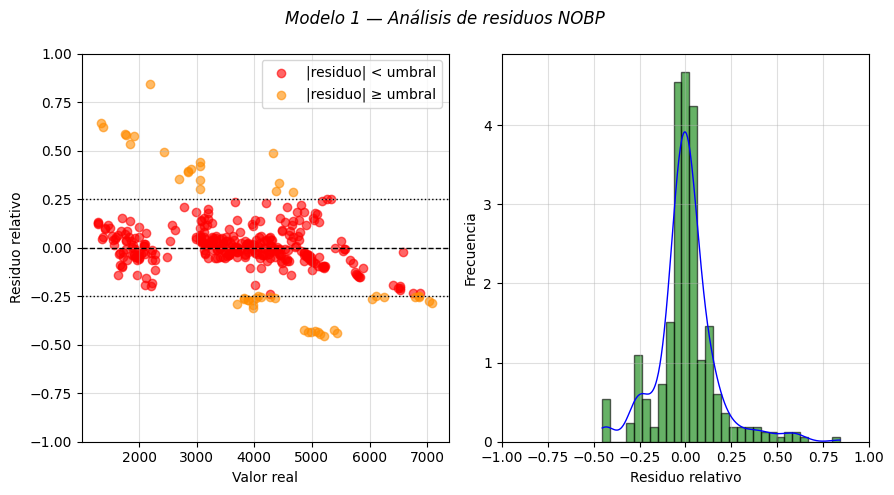

In [50]:
graficos_residuos(
    y_real_all_1,
    y_pred_all_1,
    "Modelo 1 — Análisis de residuos NOBP",
    tipo="relativo"
)

El Modelo 1, orientado a la predicción de la presión NOBP a partir de variables petrofísicas básicas (profundidad y densidad aparente), muestra un desempeño global satisfactorio al evaluarse mediante validación cruzada GroupKFold, obteniendo un R² = 0.735, un MAE de 409 psi y un RMSE de 659 psi. Estos valores indican que el modelo logra capturar correctamente la tendencia general de la variable objetivo y explica una fracción significativa de su variabilidad entre pozos.

En cuatro de los cinco folds se obtienen coeficientes de determinación R² superiores a 0.72, con errores MAE del orden de 300–400 psi y RMSE entre 430-630 psi. Sin embargo, un fold presenta un desempeño significativamente inferior (R² < 0), lo que indica la existencia de subconjuntos de pozos cuyo comportamiento no puede ser explicado adecuadamente por las variables consideradas, sugiriendo la influencia de otros parámetros petrofísicos o geológicos no incluidos en este modelo.

Los gráficos de comparación entre valores reales y predichos muestran una tendencia bien capturada por el modelo, con errores acotados (atribuibles al fold 3) y sin sesgos sistemáticos evidentes.

El análisis de residuos muestra una distribución razonablemente centrada en cero, sin sesgos sistemáticos fuertes a lo largo del rango de valores reales, aunque con colas algo extendidas, reflejando la influencia de algunos errores grandes asociados a pozos específicos. Sin embargo, la dispersión creciente para valores altos de NOBP sugiere un incremento en la incertidumbre del modelo en ese rango, aspecto consistente con la presencia de pozos atípicos observados en el gráfico de predicción. Estos pozos, resultan candidatos naturales para análisis individualizado o para estrategias de entrenamiento alternativas. La dispersión de los residuos relativos aumenta levemente para valores extremos de NOBP, lo que es esperable en modelos de presión.

Estos pozos, identificados explícitamente en los gráficos, resultan candidatos naturales para análisis individualizado o para estrategias de entrenamiento alternativas.

Finalmente, el análisis de importancia de variables indica que la profundidad es, por amplio margen, el predictor dominante del modelo, mientras que la densidad aparente aporta información adicional pero secundaria. Este resultado es coherente con la física del sistema, dado que la presión NOBP está fuertemente controlada por la columna litostática.

En conclusión, el Modelo 1 constituye una base robusta para el esquema de modelado encadenado, proporcionando predicciones razonables de NOBP que pueden ser utilizadas como variable de entrada en los modelos posteriores de porosidad y permeabilidad, con la salvedad de que los errores asociados a pozos fuera de rango deben ser tenidos en cuenta en el análisis de propagación del error.

### Optimización del modelo 1: Elimino pozos fuera del RMSE y empleo GridSearchCV

Con el objetivo de mejorar el desempeño del modelo de predicción de NOBP, se implementa una estrategia de optimización en dos etapas. En primer lugar, se identifican y excluyen del proceso de entrenamiento aquellos pozos que presentan errores significativamente elevados, definidos como observaciones por fuera del rango establecido por el RMSE. Esta depuración busca reducir la influencia de comportamientos atípicos que pueden sesgar el aprendizaje del modelo y deteriorar su capacidad de generalización.

En segundo lugar, se aborda la optimización sistemática de los hiperparámetros del algoritmo Random Forest. Si bien en las etapas iniciales se utilizaron configuraciones razonables y coherentes con el problema planteado, existe un margen adicional de mejora mediante la exploración exhaustiva de combinaciones de hiperparámetros tales como el número de árboles, la profundidad máxima, el número mínimo de muestras por hoja y la cantidad de variables consideradas en cada partición. Para este fin, se emplea la técnica de GridSearchCV, que permite evaluar de forma estructurada el impacto de estos parámetros sobre el desempeño del modelo.

La aplicación de GridSearchCV en conjunto con un esquema de validación cruzada GroupKFold, utilizando el identificador de pozo como variable de agrupamiento, garantiza que la optimización se realice bajo un criterio geológicamente consistente. De esta manera, no solo se busca maximizar métricas de desempeño global como el coeficiente de determinación (R²) y minimizar los errores (MAE y RMSE), sino también obtener modelos más estables y robustos frente a la variabilidad entre pozos. Esta etapa de optimización resulta clave para fortalecer la capacidad predictiva del modelo y su aplicabilidad en estudios de caracterización de reservorios y análisis de reservas, especialmente en contextos de elevada heterogeneidad litológica y estructural.

In [51]:
#Exclusión de los pozos fuera del RMSE para el modelo optimizado

pozos_excluir = df_fuera_rmse["Pozo"].unique()
df_filtrado = df[~df["Pozo"].isin(pozos_excluir)].copy()

print("Pozos originales:", df["Pozo"].nunique())
print("Pozos luego del filtrado:", df_filtrado["Pozo"].nunique())

groups = df_filtrado["Pozo"]

Pozos originales: 31
Pozos luego del filtrado: 20


In [52]:
#Defino que combinaciones de hiperparámetros probar

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 3, 5],
    "min_samples_split": [2, 5, 10],
}

In [53]:
# GROUP K-FOLD (Train y Test)

gkf = GroupKFold(n_splits=5)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(df_filtrado[features_m1], df_filtrado[target_m1], groups=groups)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300, 500]},
             scoring='r2', verbose=1)

In [54]:
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"Mejor R² (CV): {grid.best_score_:.3f}")

Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977


In [55]:
# GROUP K-FOLD (Train y Test)

gkf = GroupKFold(n_splits=5)

r2_scores = []
mae_scores = []
rmse_scores = []

y_real_all_1o = []
y_pred_all_1o = []
pozo_all_1o = []

In [56]:
#Entrenamiento y predicción del modelo 1 optimizado

for fold, (train_idx, test_idx) in enumerate(gkf.split(df_filtrado, groups=groups), 1):

    df_train = df_filtrado.iloc[train_idx].copy()
    df_test  = df_filtrado.iloc[test_idx].copy()

    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_nobp.fit(df_train[features_m1], df_train[target_m1])
    y_test = df_test[target_m1]
    y_pred = model_nobp.predict(df_test[features_m1])

    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

    y_real_all_1o.extend(y_test)
    y_pred_all_1o.extend(y_pred)
    pozo_all_1o.extend(df.iloc[test_idx]["Pozo"].values)

    print(f"\n===== FOLD {fold} =====")
    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R²   : {r2:.3f}")
    print(f"MAE  : {mae:.2f} psi")
    print(f"RMSE : {rmse:.2f} psi")


===== FOLD 1 =====
Pozos en test: ['Lcav-133(h)' 'PCT-350' 'PE-998' 'RN.s-2901' 'PCG-1302' 'PLMS-1018'
 'PCG-961']
R²   : 0.953
MAE  : 184.13 psi
RMSE : 207.93 psi

===== FOLD 2 =====
Pozos en test: ['Lcav-133(h)' 'RN-e.2102' 'BdC-x-1' 'PLF-986' 'PLMS-1018' 'PCG-961']
R²   : 0.988
MAE  : 102.20 psi
RMSE : 108.11 psi

===== FOLD 3 =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PCG-1302' 'PCG-1303' 'RN-e.2102']
R²   : 0.975
MAE  : 134.37 psi
RMSE : 188.08 psi

===== FOLD 4 =====
Pozos en test: ['CS-2297' 'PCHu-1013' 'PZ-1569' 'Lcav-133(h)']
R²   : 0.990
MAE  : 86.35 psi
RMSE : 109.24 psi

===== FOLD 5 =====
Pozos en test: ['EG-722' 'PZ-1632' 'PVH-1374' 'Lcav-133(h)']
R²   : 0.980
MAE  : 142.14 psi
RMSE : 178.90 psi


In [57]:
# Métricas del modelo 1 optimizado

print("\n===== MODELO 1 — RESULTADOS FINALES  Optimizado (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(y_real_all_1o, y_pred_all_1o):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_1o, y_pred_all_1o):.2f} psi")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_1o, y_pred_all_1o)):.2f} psi")


===== MODELO 1 — RESULTADOS FINALES  Optimizado (GroupKFold + GridSearchCV) =====
R²   : 0.980
MAE  : 129.66 psi
RMSE : 163.72 psi


In [58]:
#Importancia de las variables en el modelo 1 optimizado

importances_m1 = pd.DataFrame({
    "Variable": features_m1,
    "Importancia": model_nobp.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 1 OPTIMIZADO) =====")
display(importances_m1)


===== IMPORTANCIA DE VARIABLES (MODELO 1 OPTIMIZADO) =====


,Variable,Importancia
0,Profundidad,0.998876
1,Densidad Aparente,0.001124


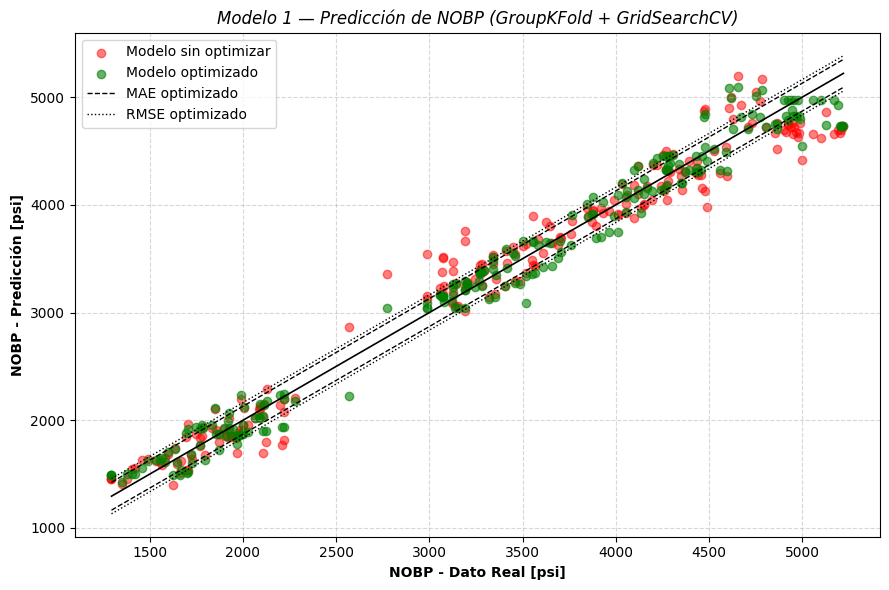

In [59]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
mask_excluidos = ~df_m1["Pozo"].isin(pozos_excluir)
plt.scatter(df_m1.loc[mask_excluidos, "y_real"],df_m1.loc[mask_excluidos, "y_pred"],color="red",alpha=0.5,label="Modelo sin optimizar")
plt.scatter(y_real_all_1o,y_pred_all_1o,color="green",alpha=0.6,label="Modelo optimizado")

lims = [
    min(min(y_real_all_1o), min(y_pred_all_1o)),
    max(max(y_real_all_1o), max(y_pred_all_1o))
]

mae_m1o = mean_absolute_error(y_real_all_1o, y_pred_all_1o)
rmse_m1o = np.sqrt(mean_squared_error(y_real_all_1o, y_pred_all_1o))

plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l + mae_m1o for l in lims], 'k--', label="MAE optimizado", linewidth=1)
plt.plot(lims, [l - mae_m1o for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l + rmse_m1o for l in lims], 'k:', label="RMSE optimizado", linewidth=1)
plt.plot(lims, [l - rmse_m1o for l in lims], 'k:', linewidth=1)

plt.xlabel("NOBP - Dato Real [psi]", fontweight='bold')
plt.ylabel("NOBP - Predicción [psi]", fontweight='bold')
plt.title("Modelo 1 — Predicción de NOBP (GroupKFold + GridSearchCV)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

La optimización del Modelo 1 mediante la eliminación de pozos con errores extremos y la búsqueda sistemática de hiperparámetros a través de GridSearchCV produjo una mejora sustancial en el desempeño predictivo del modelo de NOBP. Al comparar únicamente los pozos comunes entre el modelo original y el optimizado, se observa un incremento significativo del coeficiente de determinación, pasando de un R² de 0.735 a 0.980, acompañado por una reducción marcada de los errores absolutos y cuadráticos medios (MAE de 409.17 psi a 129.66 psi y RMSE de 658.52 psi a 163.72 psi).

Desde el punto de vista gráfico, el modelo optimizado presenta una mayor concentración de puntos alrededor de la recta 1:1 y una disminución notable de los desvíos extremos, lo que evidencia una mejora tanto en precisión como en estabilidad. Asimismo, el análisis de importancia de variables confirma que la profundidad continúa siendo el principal predictor de NOBP, mientras que la densidad aparente aporta una contribución marginal, coherente con la física del problema y reforzando la interpretabilidad del modelo.

En conjunto, estos resultados indican que la combinación de filtrado de datos anómalos y optimización de hiperparámetros no solo mejora las métricas globales, sino que conduce a un modelo más robusto y confiable para su posterior encadenamiento con los modelos de porosidad y permeabilidad, fortaleciendo la validez del enfoque de modelado propuesto.

## Modelo 2: Predicción de Porosidad STD

In [60]:
# Definición de features y target para el modelo 2

features_m2 = [
    "Profundidad",
    "Densidad Aparente",
    "NOBP_pred"
]

target_m1 = "NOBP"
target_m2 = "Porosidad STD"
groups = df["Pozo"]

gkf = GroupKFold(n_splits=5)

r2_list, mae_list, rmse_list = [], [], []

In [61]:
#Entrenamiento y predección con modelo 2

y_real_all_2 = []
y_pred_all_2 = []
pozo_all_2 = []

print("\n===== MODELO 2 — POROSIDAD STD (GroupKFold) =====")

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    # =========================
    # MODELO 1 — NOBP
    # =========================
    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_nobp.fit(df_train[features_m1], df_train[target_m1])

    df_train["NOBP_pred"] = model_nobp.predict(df_train[features_m1])
    df_test["NOBP_pred"]  = model_nobp.predict(df_test[features_m1])

    # =========================
    # MODELO 2 — POROSIDAD
    # =========================
    model_phi = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model_phi.fit(df_train[features_m2], df_train[target_m2])

    phi_pred = model_phi.predict(df_test[features_m2])

    # Métricas
    r2 = r2_score(df_test[target_m2], phi_pred)
    mae = mean_absolute_error(df_test[target_m2], phi_pred)
    rmse = np.sqrt(mean_squared_error(df_test[target_m2], phi_pred))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Guardar datos para gráfico global
    y_real_all_2.extend(df_test[target_m2].values)
    y_pred_all_2.extend(phi_pred)
    pozo_all_2.extend(df.iloc[test_idx]["Pozo"].values)

    print(f"\n===== FOLD {fold} =====")
    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R²   : {r2:.3f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")


===== MODELO 2 — POROSIDAD STD (GroupKFold) =====

===== FOLD 1 =====
Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R²   : 0.914
MAE  : 0.9952
RMSE : 1.4720

===== FOLD 2 =====
Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R²   : 0.905
MAE  : 1.3080
RMSE : 1.6914

===== FOLD 3 =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R²   : 0.855
MAE  : 1.3019
RMSE : 1.7087

===== FOLD 4 =====
Pozos en test: ['PZ-1569' 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)']
R²   : 0.934
MAE  : 1.1144
RMSE : 1.4948

===== FOLD 5 =====
Pozos en test: ['EG-722' 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdCh.s-1902'
 'AdLas-1922' 'LACh-39(h)']
R²   : 0.830
MAE  : 1.8098
RMSE : 2.6720


In [62]:
# Métricas del modelo 2

print("\n===== MODELO 2 — RESULTADOS FINALES (GroupKFold) =====")
print(f"R²   : {r2_score(y_real_all_2, y_pred_all_2):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_2, y_pred_all_2):.2f} %")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_2, y_pred_all_2)):.2f} %")


===== MODELO 2 — RESULTADOS FINALES (GroupKFold) =====
R²   : 0.893
MAE  : 1.31 %
RMSE : 1.86 %


In [63]:
#Importancia de las variables en el modelo 2

importances_m2 = pd.DataFrame({
    "Variable": features_m2,
    "Importancia": model_phi.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 2) =====")
display(importances_m2)


===== IMPORTANCIA DE VARIABLES (MODELO 2) =====


,Variable,Importancia
1,Densidad Aparente,0.967786
0,Profundidad,0.017430
2,NOBP_pred,0.014784


In [64]:
#Armo un df con los resultados identificando los pozos. Para identificar aquellos fuera del rango de MAE

mae_m2 = mean_absolute_error(y_real_all_2, y_pred_all_2)
rmse_m2 = np.sqrt(mean_squared_error(y_real_all_2, y_pred_all_2))

df_m2 = pd.DataFrame({
    "Pozo": pozo_all_2,
    "y_real": y_real_all_2,
    "y_pred": y_pred_all_2
})

df_m2["fuera_MAE"] = (
    np.abs(df_m2["y_pred"] - df_m2["y_real"]) > mae_m2)
df_fuera_mae = df_m2[df_m2["fuera_MAE"]]

df_m2["fuera_RMSE"] = (
    np.abs(df_m2["y_pred"] - df_m2["y_real"]) > rmse_m2)
df_fuera_rmse = df_m2[df_m2["fuera_RMSE"]]

print("Pozos fuera del rango MAE: ", df_fuera_mae["Pozo"].unique())
print("Pozos fuera del rango RMSE: ", df_fuera_rmse["Pozo"].unique())

Pozos fuera del rango MAE:  ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328'
 'CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LA.s-299'
 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902' 'PZ-1569'
 'RN.s-2901' 'PB-953' 'PTP-1027' 'LaCH-418(h)' 'EG-722' 'PVH-1374'
 'RN-e.2102' 'Myburg-752-792' 'AdLas-1922' 'LACh-39(h)']
Pozos fuera del rango RMSE:  ['PCHu-1013' 'PCT-350' 'PLF-986' 'PCG-1328' 'PCG-1303' 'PLMS-1018'
 'PR-1245' 'RN.a-2103' 'LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961'
 'PZ-1569' 'PB-953' 'PTP-1027' 'LaCH-418(h)' 'PVH-1374' 'RN-e.2102'
 'Myburg-752-792' 'AdLas-1922' 'LACh-39(h)']


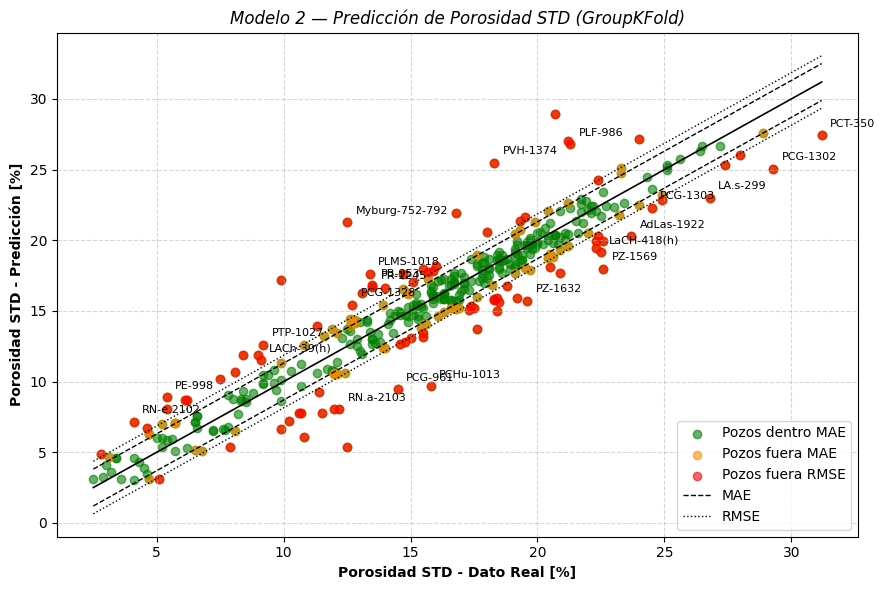

In [65]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
plt.scatter(df_m2["y_real"],df_m2["y_pred"],color="green",alpha=0.6,label="Pozos dentro MAE")
plt.scatter(df_fuera_mae["y_real"],df_fuera_mae["y_pred"],color="darkorange",alpha = 0.6,label="Pozos fuera MAE")
plt.scatter(df_fuera_rmse["y_real"],df_fuera_rmse["y_pred"],color="red",alpha = 0.6,label="Pozos fuera RMSE")

lims = [
    min(min(y_real_all_2), min(y_pred_all_2)),
    max(max(y_real_all_2), max(y_pred_all_2))
]
plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l + mae_m2 for l in lims], 'k--', label="MAE", linewidth=1)
plt.plot(lims, [l - mae_m2 for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l + rmse_m2 for l in lims], 'k:', label="RMSE", linewidth=1)
plt.plot(lims, [l - rmse_m2 for l in lims], 'k:', linewidth=1)

# Busco de los pozos fuera del RMSE, el punto más lejano para etiquetar
df_out = df_m2[df_m2["fuera_RMSE"]].copy()
df_out["dist_11"] = (df_out["y_real"] - df_out["y_pred"]).abs()
df_labels = df_out.loc[
    df_out.groupby("Pozo")["dist_11"].idxmax()
]

# Agregar etiquetas
for _, row in df_labels.iterrows():
    plt.annotate(
        row["Pozo"],
        (row["y_real"], row["y_pred"]),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=8,
        color="black"
    )

plt.xlabel("Porosidad STD - Dato Real [%]", fontweight='bold')
plt.ylabel("Porosidad STD - Predicción [%]", fontweight='bold')
plt.title("Modelo 2 — Predicción de Porosidad STD (GroupKFold)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

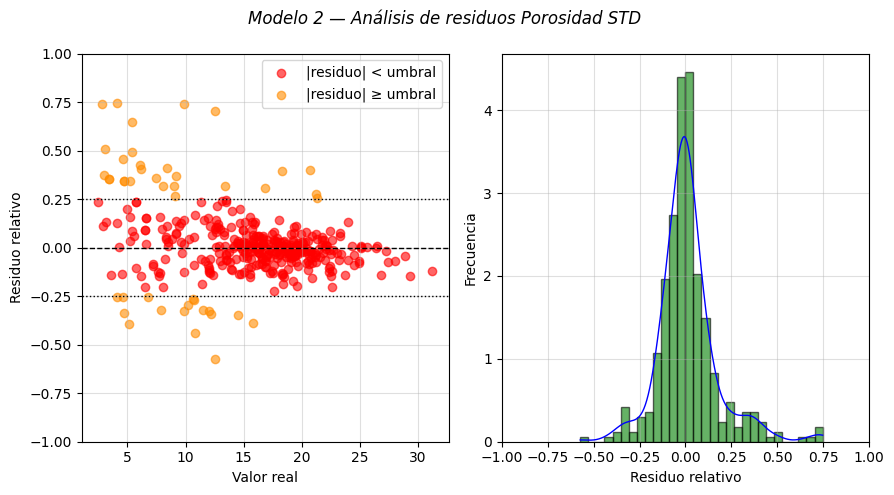

In [66]:
graficos_residuos(
    y_real=y_real_all_2,
    y_pred=y_pred_all_2,
    titulo="Modelo 2 — Análisis de residuos Porosidad STD",
    tipo="relativo"
)

El Modelo 2 presenta un alto poder predictivo para la estimación de la porosidad estándar, al ser validado mediante un esquema GroupKFold por pozo, alcanzando valores de R² comprendidos entre 0.83 y 0.93 a lo largo de los distintos folds. Asimismo, se obtienen valores de MAE promedio del orden de 1–1.3 % y RMSE típicamente inferiores al 2 %, con la excepción de un único fold más exigente. Estos resultados indican que el modelo generaliza adecuadamente a pozos no utilizados durante el entrenamiento, condición fundamental para su aplicación en escenarios reales de subsuelo.

Tal como se observa en el análisis de importancia de variables, la incorporación de la NOBP predicha (salida del Modelo 1) no presenta una influencia significativa en la predicción de porosidad, lo que sugiere que la información aportada por dicha variable es marginal frente al resto de los predictores utilizados en este modelo, siendo la densidad aparente la más significativa.

El análisis gráfico de predicción versus valor real evidencia una adecuada alineación de los datos alrededor de la recta 1:1, mientras que la distribución de los residuos se encuentra mayormente centrada en torno a cero, sin la presencia de sesgos sistemáticos marcados. No obstante, se identifican algunos pozos con errores relativamente mayores en los rangos de porosidad más bajos, los cuales pueden atribuirse tanto a la heterogeneidad geológica del sistema como a la incertidumbre inherente a las mediciones reales, particularmente en aquellos casos donde los métodos y equipos de medición presentan limitaciones e inconsistencias para valores bajos de porosidad.

En conjunto, el Modelo 2 exhibe un equilibrio adecuado entre capacidad predictiva y estabilidad, consolidándose como una etapa confiable dentro del flujo de modelado. Su desempeño respalda su utilización como entrada para modelos posteriores, especialmente para la estimación de permeabilidad, teniendo en cuenta la acumulación progresiva de incertidumbre asociada a la cadena de modelos.

En comparación con el Modelo 1 (NOBP), el Modelo 2 demuestra una mayor estabilidad, una menor dispersión entre folds y una mejor consistencia en los valores de R², lo que refuerza su robustez desde el punto de vista predictivo y su aplicabilidad en estudios petrofísicos.


###  Optimización del modelo 2: Empleo de GridSearchCV

Al igual que para el modelo 1, se realizará una optimización de hiperparámetro para tratar de ajustar el modelo 2 y conseguir mejores resultados.

In [67]:
#Entrenamiento y predección con modelo 2 optimizado

# Para gráfico global
y_real_all_2o = []
y_pred_all_2o = []
pozo_all_2o = []

r2_list, mae_list, rmse_list = [], [], []

print("\n===== MODELO 2 — POROSIDAD STD Optimizado (GroupKFold + GridSearchCV) =====")

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    # =========================
    # MODELO 1 — NOBP
    # =========================
    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_nobp.fit(df_train[features_m1], df_train[target_m1])

    df_train["NOBP_pred"] = model_nobp.predict(df_train[features_m1])
    df_test["NOBP_pred"]  = model_nobp.predict(df_test[features_m1])

    # =========================
    # MODELO 2 — POROSIDAD (Optimizado)
    # =========================
    param_grid_phi = {
        "n_estimators": [200, 300,500],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 3, 5],
        "max_features": ["sqrt", 0.8]
    }

    inner_gkf = GroupKFold(n_splits=5)

    base_model_phi = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    grid_phi = GridSearchCV(
        estimator=base_model_phi,
        param_grid=param_grid_phi,
        cv=inner_gkf,
        scoring="r2",
        n_jobs=-1,
        verbose=0
    )

    # Ajuste SOLO con datos de entrenamiento del fold
    grid_phi.fit(
        df_train[features_m2],
        df_train[target_m2],
        groups=df_train["Pozo"]
    )

    best_model_phi = grid_phi.best_estimator_

    print("Mejores hiperparámetros encontrados:")
    print(grid.best_params_)
    print(f"Mejor R² (CV): {grid.best_score_:.3f}")

    # Predicción sobre el test del fold
    phi_pred = best_model_phi.predict(df_test[features_m2])

    # Métricas
    r2 = r2_score(df_test[target_m2], phi_pred)
    mae = mean_absolute_error(df_test[target_m2], phi_pred)
    rmse = np.sqrt(mean_squared_error(df_test[target_m2], phi_pred))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Guardar datos para gráfico global
    y_real_all_2o.extend(df_test[target_m2].values)
    y_pred_all_2o.extend(phi_pred)
    pozo_all_2o.extend(df.iloc[test_idx]["Pozo"].values)

    print(f"\n===== FOLD {fold} =====")
    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R²   : {r2:.3f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}\n")


===== MODELO 2 — POROSIDAD STD Optimizado (GroupKFold + GridSearchCV) =====
Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

===== FOLD 1 =====
Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R²   : 0.877
MAE  : 1.2272
RMSE : 1.7642

Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

===== FOLD 2 =====
Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R²   : 0.920
MAE  : 1.2238
RMSE : 1.5593

Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

===== FOLD 3 =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R²   : 0.858
MAE  : 1.3116
RMSE : 1.6964

Mejores hiperparámetros encontrados:
{'max_depth'

In [68]:
# Métricas del modelo 2 optimizado

print("\n===== MODELO 2 — RESULTADOS FINALES Optimizado (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(y_real_all_2o, y_pred_all_2o):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_2o, y_pred_all_2o):.2f} %")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_2o, y_pred_all_2o)):.2f} %")


===== MODELO 2 — RESULTADOS FINALES Optimizado (GroupKFold + GridSearchCV) =====
R²   : 0.904
MAE  : 1.29 %
RMSE : 1.76 %


In [69]:
#Importancia de las variables en el modelo 2 optimizado

importances_m2 = pd.DataFrame({
    "Variable": features_m2,
    "Importancia": best_model_phi.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 2 OPTIMIZADO) =====")
display(importances_m2)


===== IMPORTANCIA DE VARIABLES (MODELO 2 OPTIMIZADO) =====


,Variable,Importancia
1,Densidad Aparente,0.738183
2,NOBP_pred,0.186668
0,Profundidad,0.075149


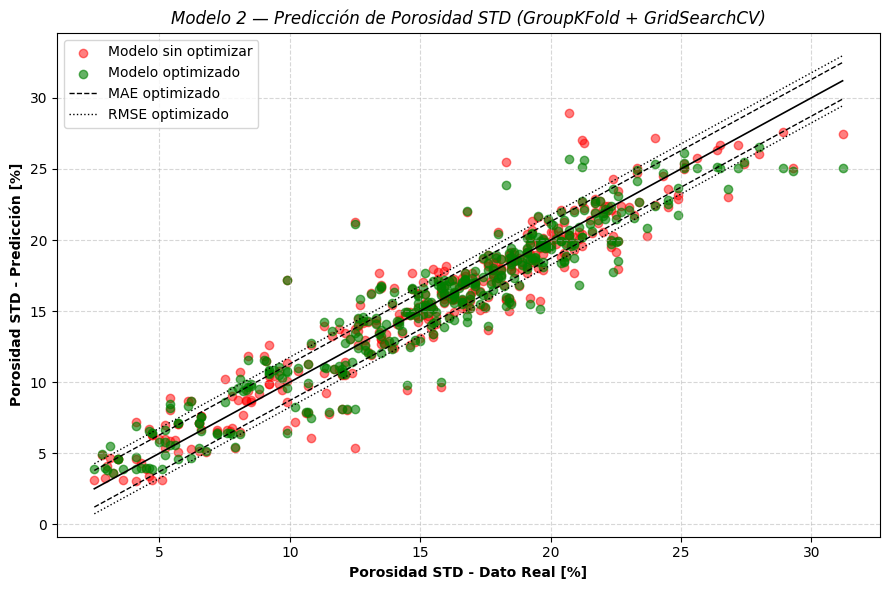

In [70]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
plt.scatter(df_m2["y_real"],df_m2["y_pred"],color="red",alpha=0.5,label="Modelo sin optimizar")
plt.scatter(y_real_all_2o,y_pred_all_2o,color="green",alpha=0.6,label="Modelo optimizado")

lims = [
    min(min(y_real_all_2o), min(y_pred_all_2o)),
    max(max(y_real_all_2o), max(y_pred_all_2o))
]

mae_m2o = mean_absolute_error(y_real_all_2o, y_pred_all_2o)
rmse_m2o = np.sqrt(mean_squared_error(y_real_all_2o, y_pred_all_2o))

plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l + mae_m2o for l in lims], 'k--', label="MAE optimizado", linewidth=1)
plt.plot(lims, [l - mae_m2o for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l + rmse_m2o for l in lims], 'k:', label="RMSE optimizado", linewidth=1)
plt.plot(lims, [l - rmse_m2o for l in lims], 'k:', linewidth=1)

plt.xlabel("Porosidad STD - Dato Real [%]", fontweight='bold')
plt.ylabel("Porosidad STD - Predicción [%]", fontweight='bold')
plt.title("Modelo 2 — Predicción de Porosidad STD (GroupKFold + GridSearchCV)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

El Modelo 2 optimizado, ajustado mediante GridSearchCV en conjunto con validación cruzada GroupKFold por pozo, mantiene un desempeño predictivo elevado y estable en la estimación de porosidad estándar. El modelo alcanza un R²= 0.904, con MAE de 1.29 % y RMSE de 1.76 %, valores comparables, y levemente superiores en términos de estabilidad a los obtenidos en la versión no optimizada.

La optimización de hiperparámetros no introduce mejoras sustanciales en las métricas globales, lo cual indica que el modelo original ya se encontraba cercano a un óptimo local para el problema planteado. No obstante, la aplicación de GridSearchCV permite reforzar la robustez del modelo, reduciendo la dependencia de elecciones arbitrarias de hiperparámetros y mejorando su consistencia frente a datos no vistos.

El análisis de importancia de variables muestra que la densidad aparente continúa siendo el principal predictor de la porosidad, concentrando aproximadamente el 74 % de la importancia total. A diferencia del modelo no optimizado, la NOBP predicha adquiere una contribución secundaria pero relevante (≈19 %). Este resultado sugiere que, bajo una calibración óptima del modelo, la información aportada por la NOBP comienza a ser aprovechada de manera más efectiva, aunque sin desplazar el rol dominante de las variables petrofísicas directas.

En términos generales, el Modelo 2 optimizado confirma la solidez del enfoque adoptado, evidenciando un adecuado balance entre capacidad predictiva, estabilidad y consistencia geológica. Su desempeño respalda su utilización como componente confiable dentro del flujo de modelado, particularmente como entrada para la estimación de permeabilidad.

## Modelo 3: Predicción de la Permeabilidad STD

In [71]:
# Definición de features y target para el modelo 3

features_m3 = [
    "Phi_pred",
    "Densidad Aparente",
    "Profundidad"
]

target_m1 = "NOBP"
target_m2 = "Porosidad STD"
target_m3 = "Permeabilidad STD"
groups = df["Pozo"]

gkf = GroupKFold(n_splits=5)

r2_list, mae_list, rmse_list = [], [], []

In [72]:
#Entrenamiento del modelo 3

# Para gráfico global
y_real_all_3 = []
y_pred_all_3 = []
pozo_all_3 = []

print("\n===== MODELO 3 — PERMEABILIDAD STD (GroupKFold) =====")

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    print(f"\n===== FOLD {fold} =====")

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    # ================================
    # MODELO 1 → NOBP
    # ================================
    X1_train = df_train[features_m1]
    y1_train = df_train["NOBP"]

    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model_nobp.fit(X1_train, y1_train)

    df_train["NOBP_pred"] = model_nobp.predict(X1_train)
    df_test["NOBP_pred"]  = model_nobp.predict(df_test[features_m1])

    # ================================
    # MODELO 2 → Porosidad
    # ================================
    X2_train = df_train[features_m2]
    y2_train = df_train["Porosidad STD"]

    model_phi = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model_phi.fit(X2_train, y2_train)

    df_train["Phi_pred"] = model_phi.predict(X2_train)
    df_test["Phi_pred"]  = model_phi.predict(df_test[features_m2])

    # ================================
    # MODELO 3 → Permeabilidad (log)
    # ================================
    X3_train = df_train[features_m3]
    X3_test  = df_test[features_m3]

    y3_train = np.log10(df_train[target_m3])
    y3_test  = np.log10(df_test[target_m3])

    model_k = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    model_k.fit(X3_train, y3_train)

    logk_pred = model_k.predict(X3_test)

    # Métricas de log(k)
    r2   = r2_score(y3_test, logk_pred)
    mae  = mean_absolute_error(y3_test, logk_pred)
    rmse = np.sqrt(mean_squared_error(y3_test, logk_pred))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Guardar datos para gráfico global
    y_real_all_3.extend(df_test[target_m3].values)
    y_pred_all_3.extend(10**logk_pred)
    pozo_all_3.extend(df.iloc[test_idx]["Pozo"].values)

    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R² (log): {r2:.3f}")
    print(f"MAE (log): {mae:.3f}")
    print(f"RMSE (log): {rmse:.3f}")


===== MODELO 3 — PERMEABILIDAD STD (GroupKFold) =====

===== FOLD 1 =====
Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R² (log): 0.232
MAE (log): 0.990
RMSE (log): 1.154

===== FOLD 2 =====
Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R² (log): 0.319
MAE (log): 0.979
RMSE (log): 1.215

===== FOLD 3 =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R² (log): 0.517
MAE (log): 0.857
RMSE (log): 1.004

===== FOLD 4 =====
Pozos en test: ['PZ-1569' 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)']
R² (log): 0.450
MAE (log): 1.122
RMSE (log): 1.366

===== FOLD 5 =====
Pozos en test: ['EG-722' 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdCh.s-1902'
 'AdLas-1922' 'LACh-39(h)']
R² (log): 0.280
MAE (log): 1.182
RMSE (log): 1.399


In [73]:
# Métricas del modelo 3

print("\n===== MODELO 3 — RESULTADOS FINALES en log (GroupKFold) =====")
print(f"R²   : {r2_score(np.log10(y_real_all_3), np.log10(y_pred_all_3)):.3f}")
print(f"MAE  : {mean_absolute_error(np.log10(y_real_all_3), np.log10(y_pred_all_3)):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(np.log10(y_real_all_3), np.log10(y_pred_all_3))):.2f}")

print("\n===== MODELO 3 — RESULTADOS FINALES en escala (GroupKFold) =====")
print(f"R²   : {r2_score(y_real_all_3, y_pred_all_3):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_3, y_pred_all_3):.2f} mD")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_3, y_pred_all_3)):.2f} mD")


===== MODELO 3 — RESULTADOS FINALES en log (GroupKFold) =====
R²   : 0.416
MAE  : 1.03
RMSE : 1.24

===== MODELO 3 — RESULTADOS FINALES en escala (GroupKFold) =====
R²   : -0.057
MAE  : 177.03 mD
RMSE : 456.46 mD


In [74]:
#Importancia de las variables en el modelo 3

importances_m3 = pd.DataFrame({
    "Variable": features_m3,
    "Importancia": model_k.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 3) =====")
display(importances_m3)


===== IMPORTANCIA DE VARIABLES (MODELO 3) =====


,Variable,Importancia
0,Phi_pred,0.592253
2,Profundidad,0.204765
1,Densidad Aparente,0.202982


In [75]:
#Armo un df con los resultados identificando los pozos. Para identificar aquellos fuera del rango de MAE

mae_m3 = mean_absolute_error(np.log10(y_real_all_3), np.log10(y_pred_all_3))
rmse_m3 = np.sqrt(mean_squared_error(np.log10(y_real_all_3), np.log10(y_pred_all_3)))

df_m3 = pd.DataFrame({
    "Pozo": pozo_all_3,
    "y_real": y_real_all_3,
    "y_pred": y_pred_all_3,
    "y_real_log": np.log10(y_real_all_3),
    "y_pred_log": np.log10(y_pred_all_3)
})

df_m3["fuera_MAE"] = (
    np.abs(df_m3["y_pred_log"] - df_m3["y_real_log"]) > mae_m3)
df_fuera_mae = df_m3[df_m3["fuera_MAE"]]

df_m3["fuera_RMSE"] = (
    np.abs(df_m3["y_pred_log"] - df_m3["y_real_log"]) > rmse_m3)
df_fuera_rmse = df_m3[df_m3["fuera_RMSE"]]

print("Pozos fuera del rango MAE: ", df_fuera_mae["Pozo"].unique())
print("Pozos fuera del rango RMSE: ", df_fuera_rmse["Pozo"].unique())

Pozos fuera del rango MAE:  ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328'
 'CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925'
 'LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902' 'PZ-1569'
 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)' 'EG-722'
 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdLas-1922' 'LACh-39(h)']
Pozos fuera del rango RMSE:  ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328'
 'CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925'
 'LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902' 'PZ-1569'
 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)' 'EG-722'
 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdLas-1922' 'LACh-39(h)']


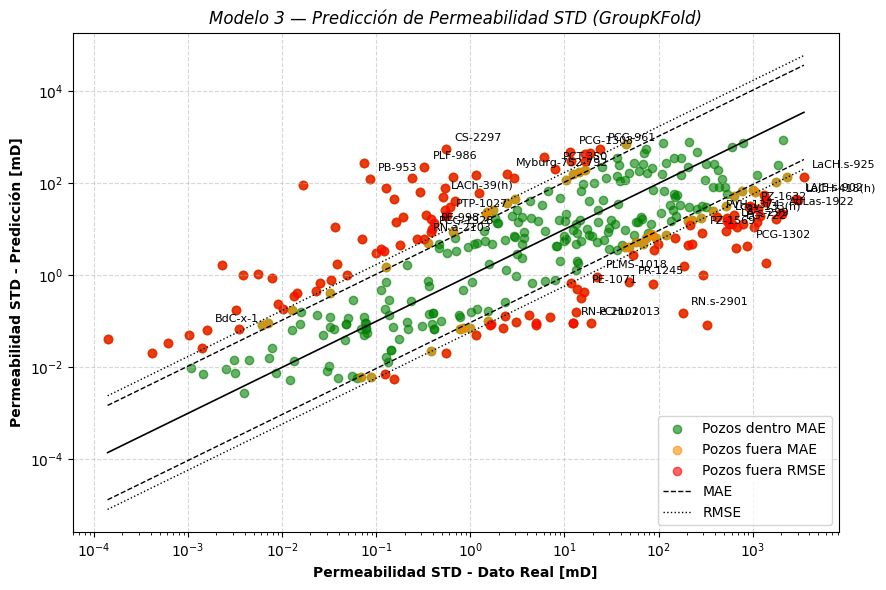

In [76]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
plt.scatter(df_m3["y_real"],df_m3["y_pred"],color="green",alpha=0.6,label="Pozos dentro MAE")
plt.scatter(df_fuera_mae["y_real"],df_fuera_mae["y_pred"],color="darkorange",alpha = 0.6,label="Pozos fuera MAE")
plt.scatter(df_fuera_rmse["y_real"],df_fuera_rmse["y_pred"],color="red",alpha = 0.6,label="Pozos fuera RMSE")

lims = [
    min(min(y_real_all_3), min(y_pred_all_3)),
    max(max(y_real_all_3), max(y_pred_all_3))
]
plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l * 10**mae_m3 for l in lims], 'k--', label="MAE", linewidth=1)
plt.plot(lims, [l * 10**-mae_m3 for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l * 10**rmse_m3 for l in lims], 'k:', label="RMSE", linewidth=1)
plt.plot(lims, [l * 10**-rmse_m3 for l in lims], 'k:', linewidth=1)

# Busco de los pozos fuera del RMSE, el punto más lejano para etiquetar
df_out = df_m3[df_m3["fuera_RMSE"]].copy()
df_out["dist_11"] = (df_out["y_real"] - df_out["y_pred"]).abs()
df_labels = df_out.loc[
    df_out.groupby("Pozo")["dist_11"].idxmax()
]

# Agregar etiquetas
for _, row in df_labels.iterrows():
    plt.annotate(
        row["Pozo"],
        (row["y_real"], row["y_pred"]),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=8,
        color="black"
    )

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Permeabilidad STD - Dato Real [mD]", fontweight='bold')
plt.ylabel("Permeabilidad STD - Predicción [mD]", fontweight='bold')
plt.title("Modelo 3 — Predicción de Permeabilidad STD (GroupKFold)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

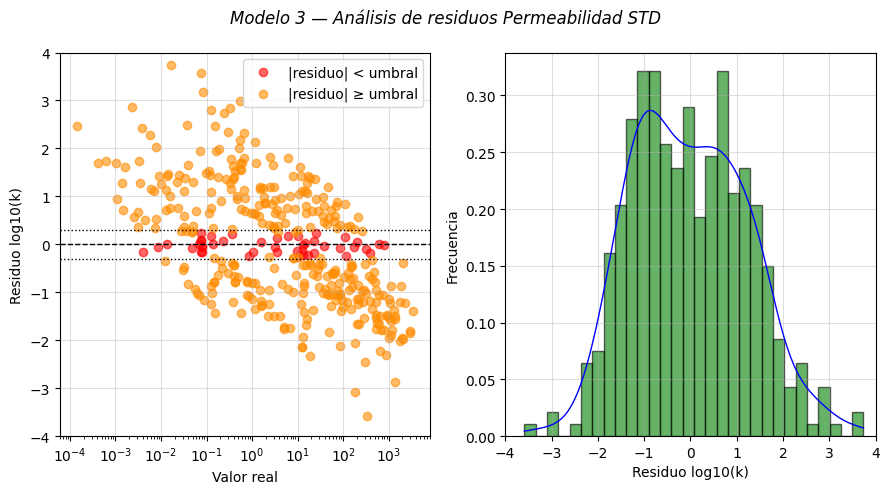

In [77]:
graficos_residuos(
    y_real=y_real_all_3,
    y_pred=y_pred_all_3,
    titulo="Modelo 3 — Análisis de residuos Permeabilidad STD",
    tipo="log"
)

El Modelo 3, orientado a la predicción de permeabilidad, logra capturar la tendencia logarítmica global de la variable, aunque presenta una elevada dispersión y una marcada compresión del rango dinámico. Este comportamiento se explica, en gran medida, por la acumulación de errores provenientes de los modelos previos y por la naturaleza altamente no lineal de la permeabilidad, parámetro particularmente sensible a pequeñas variaciones petrofísicas y geológicas.

Se observa de manera sistemática que las permeabilidades altas tienden a ser subestimadas, mientras que las permeabilidades muy bajas resultan sobreestimadas, reflejando una pérdida de sensibilidad del modelo en los extremos del dominio. Esta limitación se acentúa al transformar los resultados desde la escala logarítmica a la escala real, donde se evidencia un deterioro del desempeño cuantitativo.

Los resultados obtenidos, con un R² en escala logarítmica de 0.416, un MAE (log) de aproximadamente 1.03 y un RMSE (log) de hasta 1.24, indican que la permeabilidad es un parámetro intrínsecamente difícil de predecir a partir de las variables disponibles y altamente dependiente de la litología y de la heterogeneidad del sistema. Si bien el R² en escala real no resulta representativo del desempeño del modelo, dado que el ajuste se realiza en escala logarítmica, los valores de MAE y RMSE en escala real (del orden de 180 mD y 460 mD, respectivamente) evidencian desvíos significativos. Estas magnitudes son particularmente relevantes en términos de ingeniería de reservorios, donde diferencias del orden de 100 mD pueden implicar escenarios de productividad y comportamiento del yacimiento completamente distintos.

Desde un punto de vista práctico, el modelo resulta útil para una clasificación cualitativa de permeabilidad (baja, media y alta), pero no confiable para estimaciones cuantitativas directas de k en escala real.

El análisis de importancias de variables muestra que todas las variables contribuyen a la predicción, destacándose la porosidad predicha como la de mayor peso, lo cual es consistente con su rol físico y con el hecho de que incorpora, de manera indirecta, la información proveniente de la NOBP predicha en etapas anteriores del flujo.

Finalmente, el análisis de residuos del modelo de permeabilidad revela una distribución altamente asimétrica y una dispersión marcada a lo largo de todo el rango de permeabilidades, con un comportamiento claramente heterocedástico. Se observan errores relativos extremadamente grandes —tanto positivos como negativos— especialmente en los extremos de k, lo cual es coherente con la física del problema: pequeñas variaciones en porosidad, presión o densidad pueden generar cambios abruptos en la permeabilidad.

En consecuencia, el Modelo 3 es adecuado para análisis en escala logarítmica y para la identificación de tendencias globales de permeabilidad, pero no debe utilizarse para la predicción puntual de valores absolutos de k en escala real, particularmente en el dominio de bajas permeabilidades. Su aplicación se recomienda principalmente para estudios comparativos, zonificación petrofísica o análisis exploratorios, requiriendo tratamientos adicionales o información complementaria para usos cuantitativos más exigentes.

### Optimización del modelo 3: Empleo de GridSearchCV

Se buscarán los hiperparámetros óptimos para ver si se logra mejorar la capacidad predictiva del modelo.

In [78]:
#Entrenamiento del modelo 3 optimizado

# Para gráfico global
y_real_all_3o = []
y_pred_all_3o = []
pozo_all_3o = []

r2_list, rmse_list, mae_list = [], [], []

print("\n===== MODELO 3 — PERMEABILIDAD STD Optimizado (GroupKFold + GridSearchCV) =====")

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    print(f"\n===== FOLD {fold} =====")

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    # ================================
    # MODELO 1 → NOBP
    # ================================
    X1_train = df_train[features_m1]
    y1_train = df_train["NOBP"]

    model_nobp = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model_nobp.fit(X1_train, y1_train)

    df_train["NOBP_pred"] = model_nobp.predict(X1_train)
    df_test["NOBP_pred"]  = model_nobp.predict(df_test[features_m1])

    # ================================
    # MODELO 2 → Porosidad
    # ================================
    X2_train = df_train[features_m2]
    y2_train = df_train["Porosidad STD"]

    model_phi = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    model_phi.fit(X2_train, y2_train)

    df_train["Phi_pred"] = model_phi.predict(X2_train)
    df_test["Phi_pred"]  = model_phi.predict(df_test[features_m2])

    # ================================
    # MODELO 3 → Permeabilidad (log) Optimizado
    # ================================

    param_grid_logk = {
        "n_estimators": [200, 300,500],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 3, 5],
        "max_features": ["sqrt", 0.8]
    }

    inner_gkf = GroupKFold(n_splits=5)

    base_model_logk = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    grid_logk = GridSearchCV(
        estimator=base_model_logk,
        param_grid=param_grid_logk,
        cv=inner_gkf,
        scoring="r2",
        n_jobs=-1,
        verbose=0
    )

    # Ajuste SOLO con datos de entrenamiento del fold
    grid_logk.fit(
        df_train[features_m3],
        np.log10(df_train[target_m3]),
        groups=df_train["Pozo"]
    )

    best_model_logk = grid_logk.best_estimator_

    print("Mejores hiperparámetros encontrados:")
    print(grid.best_params_)
    print(f"Mejor R² (CV): {grid.best_score_:.3f}")

    # Predicción sobre el test del fold
    logk_pred = best_model_logk.predict(df_test[features_m3])

    # Métricas de log(k)
    r2   = r2_score(np.log10(df_test[target_m3]), logk_pred)
    mae  = mean_absolute_error(np.log10(df_test[target_m3]), logk_pred)
    rmse = np.sqrt(mean_squared_error(np.log10(df_test[target_m3]), logk_pred))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Guardar datos para gráfico global
    y_real_all_3o.extend(df_test[target_m3].values)
    y_pred_all_3o.extend(10**logk_pred)
    pozo_all_3o.extend(df.iloc[test_idx]["Pozo"].values)

    print("\nPozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R² (log): {r2:.3f}")
    print(f"MAE (log): {mae:.3f}")
    print(f"RMSE (log): {rmse:.3f}")


===== MODELO 3 — PERMEABILIDAD STD Optimizado (GroupKFold + GridSearchCV) =====

===== FOLD 1 =====
Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R² (log): 0.309
MAE (log): 0.912
RMSE (log): 1.094

===== FOLD 2 =====
Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R² (log): 0.475
MAE (log): 0.841
RMSE (log): 1.066

===== FOLD 3 =====
Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Mejor R² (CV): 0.977

Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R² (log): 0.552
MAE (log): 0.833
RMSE (log): 0.967

===== FOLD 4 =

In [79]:
# Métricas del modelo 3 optimizado

print("\n===== MODELO 3 — RESULTADOS FINALES en log (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(np.log10(y_real_all_3o), np.log10(y_pred_all_3o)):.3f}")
print(f"MAE  : {mean_absolute_error(np.log10(y_real_all_3o), np.log10(y_pred_all_3o)):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(np.log10(y_real_all_3o), np.log10(y_pred_all_3o))):.2f}")

print("\n===== MODELO 3 — RESULTADOS FINALES en escala (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(y_real_all_3o, y_pred_all_3o):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_3o, y_pred_all_3o):.2f} mD")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_3o, y_pred_all_3o)):.2f} mD")


===== MODELO 3 — RESULTADOS FINALES en log (GroupKFold + GridSearchCV) =====
R²   : 0.479
MAE  : 0.97
RMSE : 1.17

===== MODELO 3 — RESULTADOS FINALES en escala (GroupKFold + GridSearchCV) =====
R²   : -0.057
MAE  : 167.13 mD
RMSE : 456.32 mD


In [80]:
#Importancia de las variables en el modelo 3 optimizado

importances_m3 = pd.DataFrame({
    "Variable": features_m3,
    "Importancia": best_model_logk.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 3) Optimizado =====")
display(importances_m3)


===== IMPORTANCIA DE VARIABLES (MODELO 3) Optimizado =====


,Variable,Importancia
0,Phi_pred,0.382483
1,Densidad Aparente,0.354290
2,Profundidad,0.263228


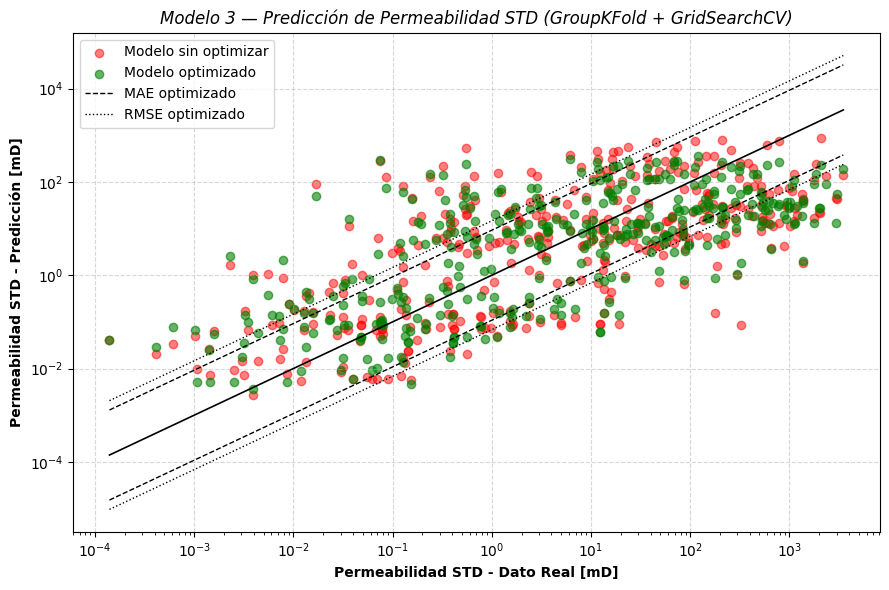

In [81]:
#Gráfica de resultados

plt.figure(figsize=(9,6))
plt.scatter(df_m3["y_real"],df_m3["y_pred"],color="red",alpha=0.5,label="Modelo sin optimizar")
plt.scatter(y_real_all_3o,y_pred_all_3o,color="green",alpha=0.6,label="Modelo optimizado")

lims = [
    min(min(y_real_all_3o), min(y_pred_all_3o)),
    max(max(y_real_all_3o), max(y_pred_all_3o))
]

mae_m3o = mean_absolute_error(np.log10(y_real_all_3o), np.log10(y_pred_all_3o))
rmse_m3o = np.sqrt(mean_squared_error(np.log10(y_real_all_3o), np.log10(y_pred_all_3o)))

plt.plot(lims, lims, 'k', linewidth=1.2)
plt.plot(lims, [l *10**mae_m3o for l in lims], 'k--', label="MAE optimizado", linewidth=1)
plt.plot(lims, [l *10**-mae_m3o for l in lims], 'k--', linewidth=1)
plt.plot(lims, [l *10**rmse_m3o for l in lims], 'k:', label="RMSE optimizado", linewidth=1)
plt.plot(lims, [l *10**-rmse_m3o for l in lims], 'k:', linewidth=1)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Permeabilidad STD - Dato Real [mD]", fontweight='bold')
plt.ylabel("Permeabilidad STD - Predicción [mD]", fontweight='bold')
plt.title("Modelo 3 — Predicción de Permeabilidad STD (GroupKFold + GridSearchCV)", fontstyle='italic')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

La optimización del Modelo 3 mediante GridSearchCV produce una mejora moderada pero consistente en la predicción en escala logarítmica, con un incremento del R² de 0.42 a 0.48 y una reducción del MAE (log) de 1.03 a 0.97 y del RMSE (log) de 1.24 a 1.17. Esto indica que la optimización de hiperparámetros permite capturar de manera algo más eficiente la tendencia global de la permeabilidad en escala logarítmica, aunque sin resolver completamente la alta dispersión inherente al problema.

Un aspecto relevante de la optimización se observa en el reordenamiento de las importancias de las variables. Mientras que en el modelo no optimizado la porosidad predicha dominaba claramente la predicción, en el modelo optimizado su importancia relativa disminuye, dando mayor peso a la densidad aparente y a la profundidad. Este cambio sugiere un modelo menos dependiente de una única variable encadenada y una mayor diversificación de la información explicativa, lo cual contribuye a una mayor estabilidad del ajuste en escala logarítmica, aunque no se traduce en una mejora sustancial en la predicción cuantitativa de k en escala real.

En conjunto, el Modelo 3 optimizado confirma que la permeabilidad sigue siendo el parámetro más desafiante del flujo de modelado, altamente sensible a la heterogeneidad geológica y a la propagación de incertidumbre desde los modelos previos. La optimización mejora marginalmente el ajuste en log(k) y redistribuye las contribuciones de las variables de entrada, pero no modifica la conclusión principal: el modelo resulta adecuado para análisis de tendencias, clasificación cualitativa y estudios comparativos, pero no es confiable para estimaciones puntuales de permeabilidad en escala real sin un tratamiento adicional.

## Propagación del error por modelos encadenados

Dado que los modelos desarrollados siguen una estructura secuencial o encadenada, en la cual la salida de un modelo se utiliza como entrada del siguiente, es esperable que los errores de predicción se propaguen y, potencialmente, se amplifiquen a lo largo de la cadena de modelado.

En particular, el Modelo 1 (predicción de NOBP) introduce un primer nivel de incertidumbre que impacta directamente en el Modelo 2, donde la porosidad es estimada utilizando, entre otras variables, la NOBP predicha. A su vez, el Modelo 3 emplea como entrada la porosidad estimada por el Modelo 2, acumulando la incertidumbre proveniente de ambos modelos anteriores.

A fin de cuantificar la propagación del error asociada al uso de modelos encadenados, se plantea un escenario de referencia en el cual la permeabilidad es estimada utilizando como variables de entrada los valores reales de NOBP y porosidad, en lugar de los valores predichos por los Modelos 1 y 2.

De este modo, se entrena un modelo alternativo de permeabilidad bajo condiciones ideales, donde no existe error acumulado proveniente de etapas previas. La comparación entre las métricas obtenidas en este caso y aquellas correspondientes al modelo encadenado permite cuantificar de manera directa el impacto de la propagación del error en el desempeño del Modelo 3.

In [82]:
features_m3_real = [
    "Porosidad STD",
    "Densidad Aparente",
    "Profundidad",
    "NOBP"
]

groups = df["Pozo"]
gkf = GroupKFold(n_splits=5)

y_real_all_3r = []
y_pred_all_3r = []
pozo_all_3r = []

r2_list, rmse_list, mae_list = [], [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups), 1):

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    print(f"\n===== FOLD {fold} — MODELO 3A (REAL) =====")

    X3_train = df_train[features_m3_real]
    X3_test  = df_test[features_m3_real]

    y3_train = np.log10(df_train[target_m3])
    y3_test  = np.log10(df_test[target_m3])

    model_k_real = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model_k_real.fit(X3_train, y3_train)

    logk_pred = model_k_real.predict(X3_test)

    # Métricas de log(k)
    r2   = r2_score(y3_test, logk_pred)
    mae  = mean_absolute_error(y3_test, logk_pred)
    rmse = np.sqrt(mean_squared_error(y3_test, logk_pred))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    # Guardar datos para gráfico global
    y_real_all_3r.extend(df_test[target_m3].values)
    y_pred_all_3r.extend(10**logk_pred)
    pozo_all_3r.extend(df.iloc[test_idx]["Pozo"].values)

    print("Pozos en test:", df.iloc[test_idx]["Pozo"].astype(str).unique())
    print(f"R² (log): {r2:.3f}")
    print(f"MAE (log): {mae:.3f}")
    print(f"RMSE (log): {rmse:.3f}")

# ================================
# Métricas globales
# ================================
print("\n===== MODELO 3 — RESULTADOS FINALES en log REAL -sin inputs de predicción- (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(np.log10(y_real_all_3r), np.log10(y_pred_all_3r)):.3f}")
print(f"MAE  : {mean_absolute_error(np.log10(y_real_all_3r), np.log10(y_pred_all_3r)):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(np.log10(y_real_all_3r), np.log10(y_pred_all_3r))):.2f}")

print("\n===== MODELO 3 — RESULTADOS FINALES en escala REAL -sin inputs de predicción- (GroupKFold + GridSearchCV) =====")
print(f"R²   : {r2_score(y_real_all_3r, y_pred_all_3r):.3f}")
print(f"MAE  : {mean_absolute_error(y_real_all_3r, y_pred_all_3r):.2f} mD")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real_all_3r, y_pred_all_3r)):.2f} mD")


# ================================
# Importancias
# ================================

importances_m3_real = pd.DataFrame({
    "Variable": features_m3_real,
    "Importancia": model_k_real.feature_importances_
}).sort_values("Importancia", ascending=False)

print("\n===== IMPORTANCIA DE VARIABLES (MODELO 3) sin inputs de predicción =====")
display(importances_m3_real)


===== FOLD 1 — MODELO 3A (REAL) =====
Pozos en test: ['PCHu-1013' 'Lcav-133(h)' 'PCT-350' 'PLF-986' 'PE-1071' 'PCG-1328']
R² (log): 0.233
MAE (log): 0.961
RMSE (log): 1.153

===== FOLD 2 — MODELO 3A (REAL) =====
Pozos en test: ['CS-2297' 'PCG-1303' 'PLMS-1018' 'PR-1245' 'RN.a-2103' 'LaCH.s-925']
R² (log): 0.403
MAE (log): 0.923
RMSE (log): 1.137

===== FOLD 3 — MODELO 3A (REAL) =====
Pozos en test: ['LA.s-299' 'PZ-1632' 'PE-998' 'PCG-1302' 'PCG-961' 'LAJE.s-902']
R² (log): 0.440
MAE (log): 0.935
RMSE (log): 1.081

===== FOLD 4 — MODELO 3A (REAL) =====
Pozos en test: ['PZ-1569' 'RN.s-2901' 'BdC-x-1' 'PB-953' 'PTP-1027' 'LaCH-418(h)']
R² (log): 0.434
MAE (log): 1.132
RMSE (log): 1.386

===== FOLD 5 — MODELO 3A (REAL) =====
Pozos en test: ['EG-722' 'PVH-1374' 'RN-e.2102' 'Myburg-752-792' 'AdCh.s-1902'
 'AdLas-1922' 'LACh-39(h)']
R² (log): 0.373
MAE (log): 1.124
RMSE (log): 1.305

===== MODELO 3 — RESULTADOS FINALES en log REAL -sin inputs de predicción- (GroupKFold + GridSearchCV) =====


,Variable,Importancia
1,Densidad Aparente,0.612707
0,Porosidad STD,0.198943
2,Profundidad,0.118456
3,NOBP,0.069894


En compativa, en escala logarítmica, el modelo sin inputs predichos alcanza un R² = 0.43, con MAE = 1.02 y RMSE = 1.22, valores muy similares a los obtenidos por el modelo encadenado optimizado (R² = 0.48, MAE = 0.97, RMSE = 1.17). Esta comparación indica que la incorporación de NOBP y porosidad predichas no degrada de forma significativa el desempeño en log(k) y que la mayor fuente de error no proviene de la propagación desde los modelos previos, sino de la complejidad intrínseca del fenómeno físico que gobierna la permeabilidad.

En escala real, ambos enfoques presentan un desempeño prácticamente equivalente y limitado, con R² negativos y errores absolutos del orden de 170–460 mD, confirmando que la pérdida de desempeño al revertir la transformación logarítmica no está dominada por la cadena de modelos, sino por la fuerte no linealidad y el amplio rango dinámico de la permeabilidad.

El análisis de importancias refuerza esta interpretación. En el modelo sin inputs predichos, la densidad aparente domina claramente la predicción, mientras que la porosidad real y la NOBP real presentan contribuciones secundarias. Al comparar con el modelo encadenado optimizado, se observa que la porosidad predicha gana peso relativo, pero sin alterar de manera sustancial el desempeño global. Esto sugiere que el Modelo 3 es estructuralmente más sensible a propiedades físicas directamente relacionadas con la matriz rocosa, y menos dependiente del origen (real o predicho) de las variables petrofísicas intermedias.

En conjunto, estos resultados indican que la propagación de errores desde los Modelos 1 y 2 hacia el Modelo 3 es limitada y no constituye el principal factor que restringe la calidad de la predicción de permeabilidad. La principal limitación radica en la naturaleza altamente heterogénea, no lineal y multiescalar de la permeabilidad, lo que impone un techo natural al desempeño del modelo, incluso cuando se utilizan variables de entrada medidas directamente. Por lo tanto, el uso de modelos encadenados resulta metodológicamente válido para análisis comparativos y de zonificación, siempre que se reconozcan las limitaciones.

# Proyección e implementación

El enfoque de modelado desarrollado en este trabajo puede implementarse como una herramienta dinámica de apoyo a la toma de decisiones para la caracterización petrofísica y evaluación de reservorios en contextos donde la información disponible es parcial, heterogénea o se encuentra distribuida de forma desigual entre pozos.

Una de las principales ventajas de esta metodología es su capacidad de crecimiento continuo. A medida que se incorporen nuevos pozos, mediciones y registros, el dataset puede ampliarse y los modelos reentrenarse de forma periódica, mejorando progresivamente su capacidad de generalización y reduciendo la incertidumbre asociada a las predicciones. Este enfoque iterativo permite que el sistema evolucione junto con el conocimiento del yacimiento, en lugar de constituir una solución estática.

Las predicciones generadas pueden utilizarse de forma espacialmente integrada, permitiendo analizar los resultados por zonas, intervalos o dominios geológicos, en lugar de interpretarlos únicamente a nivel puntual. De este modo, los modelos resultan especialmente útiles para:

* Estudios exploratorios preliminares

* Identificación de tendencias regionales

* Comparación relativa entre áreas y niveles estratigráficos

* Priorización de zonas con mayor potencial productivo

En pozos futuros o en pozos existentes donde no sea posible obtener mediciones reales confiables (por limitaciones operativas, económicas o técnicas), este enfoque permite completar información faltante de manera consistente, aportando estimaciones coherentes con el comportamiento observado en el resto del campo. Si bien estas predicciones no reemplazan a las mediciones directas, constituyen una base sólida para análisis exploratorios, planificación de campañas de adquisición de datos y evaluación temprana del potencial productivo.

En conjunto, esta metodología ofrece un marco flexible y escalable para integrar datos, explorar escenarios y apoyar decisiones técnicas en etapas tempranas y de desarrollo, especialmente en sistemas complejos y heterogéneos, donde la disponibilidad de información completa es limitada. Más aún, es posible ampliar el desarrollo sumando modelos para la predicción de la porosidad NOBP y la permeabilidad NOBP encadenados a los modelos anteriores y sumando mayor información relevante.

#Conclusiones


En el presente trabajo se desarrolló un análisis integral de un conjunto de datos petrofísicos de laboratorio correspondiente a muestras de roca provenientes de distintos pozos y áreas productivas de la industria Oil & Gas en Argentina. El objetivo principal fue evaluar la posibilidad de predecir propiedades petrofísicas clave —porosidad, permeabilidad y presión de confinamiento (NOBP)— a partir de variables más accesibles, con aplicación directa en el análisis de reservorios y la alimentación de simuladores dinámicos.

En una primera etapa, se llevó a cabo un exhaustivo proceso de exploración, limpieza y transformación del dataset, eliminando aproximadamente el 23,9% de los registros originales. Si bien esta reducción es significativa, permitió garantizar la consistencia, completitud y calidad de la información, condición indispensable para el análisis estadístico y el entrenamiento de modelos predictivos confiables. El análisis estadístico preliminar evidenció una marcada heterogeneidad en las propiedades petrofísicas, coherente con la presencia de múltiples unidades estratigráficas y distintos grados de compactación y calidad de reservorio.

Posteriormente, el estudio de correlaciones mediante los coeficientes de Pearson y Spearman permitió identificar relaciones físicas esperadas y robustas, tales como:

- La fuerte correlación entre profundidad y NOBP.
- La relación inversa muy marcada entre densidad aparente y porosidad.
- La elevada redundancia entre mediciones en condiciones STD y NOBP para porosidad y permeabilidad.

Asimismo, se constató que la densidad de grano presenta escasa variabilidad y nula correlación con el resto de las variables, por lo que se descartó como predictor relevante.

Con base en estos resultados, se definió una estrategia de aprendizaje supervisado con modelos encadenados, en la cual se utilizaron variables de fácil medición (profundidad y densidad aparente) como inputs principales para predecir propiedades más complejas. Se seleccionó el algoritmo Random Forest debido a su capacidad para capturar relaciones no lineales, su robustez frente a ruido y outliers, y su idoneidad para datasets heterogéneos como los petrofísicos.

Los resultados obtenidos con los tres modelos entrenados fueron consistentes y reveladores:

- El modelo de predicción de NOBP mostró un desempeño sólido (R² ≈ 0,98), confirmando que la presión de confinamiento puede ser estimada con buena precisión a partir de variables estructurales.

- El modelo de predicción de porosidad presentó un desempeño excelente (R² ≈ 0,90), demostrando que la porosidad es altamente predecible a partir de la densidad aparente y la profundidad, en línea con los fundamentos físicos del empaquetamiento y la compactación de granos.

- El modelo de predicción de permeabilidad, aun trabajando en escala logarítmica, mostró un desempeño bajo, útil para escalabilidad cualitativa, reflejando la complejidad inherente de esta propiedad y su fuerte dependencia de factores no incluidos explícitamente en el dataset, como la conectividad de poros y la litología de la roca, entre otros parámetros.

En conjunto, los resultados validan que es viable y consistente aplicar modelos de aprendizaje supervisado para la predicción de propiedades petrofísicas, especialmente porosidad y NOBP, utilizando un conjunto reducido de variables explicativas.

Finalmente, este trabajo sienta una base sólida para desarrollos futuros, tales como la segmentación por zonas, la incorporación de información geológica adicional y la integración de estos modelos en trabajos de simulación de reservorios, contribuyendo a la reducción de incertidumbre y a una toma de decisiones más eficiente.

In [83]:
!cp "/content/drive/MyDrive/Colab Notebooks/TP final García Quenardelle_Final.ipynb" /content

In [84]:
#Para llevar a Git
!jupyter nbconvert "TP final García Quenardelle_Final.ipynb" \
  --to notebook \
  --ClearMetadataPreprocessor.enabled=True \
  --inplace

[NbConvertApp] Converting notebook TP final García Quenardelle_Final.ipynb to notebook
[NbConvertApp] Writing 3784365 bytes to TP final García Quenardelle_Final.ipynb


###